<img src = "https://drive.google.com/uc?export=view&id=1Hh_G3M13P9xSNgSiQ-WnALg93XwK_hG8" alt = "Encabezado MLDS" width = "100%">  </img>

 # MACROPULSE MODEL
 ## Optimización de Portafolios con LSTM, Sentimiento de la FED y dinámica de ciclos económicos

**Integrantes:**
- Adriana Valderrama — adrianavalderrama11@gmail.com
- Luis Felipe Tolosa — ltolosas@unal.edu.co
- Michael Betancourt — msbetancourtge@unal.edu.co

---
**Objetivo:** Predecir retornos mensuales de 9 activos usando un LSTM que integra señales NLP de la FED, variables macroeconómicas (niveles + deltas) y retornos históricos, para alimentar un optimizador de portafolios de Markowitz.

# **FASE 1**
# **Entendimiento del Negocio y Carga de Datos**
---

## 1. Trasfondo del Negocio

**Dominio:** Finanzas cuantitativas y Gestión de portafolios de inversión.

**Beneficiarios:** Inversionistas que buscan asignar capital entre múltiples clases de activos (tecnología, energía, consumo defensivo, utilities, banca y renta fija) de forma sistemática y fundamentada.

**Problema del dominio:** La asignación de activos tradicionalmente se basa en retornos históricos y covarianzas estáticas, ignorando dos señales que mueven los mercados:

1. **Los ciclos macroeconómicos rotan, qué sectores generan valor.** En expansión, los cíclicos (tech, energía) lideran; en contracción, los defensivos (utilities, bonos, consumo básico) protegen el capital. Un portafolio que no se adapta al régimen macro deja rendimiento sobre la mesa o asume riesgo innecesario.

2. **La postura de la Reserva Federal amplifica o amortigua estos ciclos.** Un tono hawkish encarece el crédito y castiga a growth stocks; un tono dovish inyecta liquidez y favorece activos de riesgo. Esta señal cualitativa, contenida en los comunicados FOMC, no se captura con datos numéricos tradicionales.

El problema no consiste simplemente en predecir precios, sino en entender cómo el mercado responde a un entorno dinámico compuesto por condiciones económicas, decisiones de política monetaria y el comportamiento reciente de los activos. El inversionista promedio no tiene herramientas para procesar simultáneamente estas tres dimensiones y tomar decisiones de asignación óptima cada mes.

## 2. Objetivo del Proyecto

Desarrollar **MacroPulse**, un sistema de predicción de retornos mensuales basado en un LSTM multi-output que genera estimaciones *forward-looking* — anticipando el comportamiento futuro de los activos incorporando no solo su historia, sino también el contexto económico y monetario en el que operan.

El modelo integra tres fuentes clave de información:
- **Datos de mercado:** Retornos históricos mensuales de 9 activos (AMD, GOOGL, AGG, XOM, JNJ, WMT, CM, DUK, BNS).
- **Variables macroeconómicas:** Inflación, desempleo, producción industrial, curva de rendimiento, VIX, spreads crediticios, M2 y petróleo — en niveles y deltas (dirección del cambio).
- **Señales de política monetaria:** Hawkish Index construido mediante NLP (FinBERT) a partir de los comunicados FOMC de la FED.

Las predicciones alimentan un optimizador de portafolios de Markowitz con covarianza robusta (Ledoit-Wolf) para generar pesos de inversión óptimos mensualmente, maximizando el ratio de Sharpe bajo restricciones de diversificación.

## 3. ¿Por qué un LSTM?

Un LSTM es especialmente adecuado para este problema porque pertenece a la familia de redes neuronales recurrentes diseñadas para datos secuenciales, donde el orden temporal y la historia de las variables son fundamentales. A diferencia de modelos tradicionales (regresiones, redes densas), el LSTM captura:

**Dependencias temporales:** El comportamiento del mercado depende de cómo *evolucionan* las variables, no solo de su valor actual. Una inflación alta no tiene el mismo efecto si viene bajando que si viene subiendo. Un tono hawkish de la FED es más relevante si representa un cambio reciente frente a una tendencia estable.

**Efectos rezagados:** Cambios en la política monetaria afectan al mercado con retraso; la inflación impacta el consumo gradualmente. **El LSTM aprende estos patrones de retraso de forma implícita**, sin necesidad de especificarlos manualmente. Al trabajar con variables macro y sus rezagos, la ventana de 6 meses permite que las señales tengan mayor varianza de información y potencialmente mayor poder predictivo sobre ciclos de negocio.

**Persistencia y cambios de régimen:** Los mercados se mueven en fases — períodos de alta o baja volatilidad, entornos monetarios restrictivos o expansivos. El LSTM identifica patrones persistentes y detecta transiciones entre estados, clave para modelar tanto retornos como riesgo.

**Interacciones no lineales:** El impacto del desempleo puede depender del nivel de inflación; el efecto del Hawkish Index varía según el contexto de tasas de interés. El LSTM captura estas interacciones sin necesidad de definirlas explícitamente.

**Integración de señales heterogéneas:** El modelo combina datos numéricos (inflación, retornos) con datos derivados de texto (Hawkish Index), procesándolos como una secuencia conjunta donde aprende cómo estas señales evolucionan e interactúan para influir en el mercado.

En este contexto, el modelo no busca "adivinar" el mercado, sino proporcionar mejores insumos para la toma de decisiones en la construcción de portafolios — transformando un enfoque tradicional basado en promedios históricos en un sistema más dinámico, contextual y alineado con el comportamiento real de los mercados.

## 4. Valor para el Inversionista

- **Decisiones basadas en datos, no en intuición.** El modelo cuantifica objetivamente el impacto del ciclo macro y la postura de la FED sobre cada sector, eliminando sesgos cognitivos.
- **Rotación sectorial anticipada.** Al incorporar deltas macroeconómicos (dirección del cambio), el modelo detecta transiciones de régimen antes de que se reflejen completamente en los precios.
- **Diversificación inteligente.** La restricción de peso máximo (25% por activo) y la covarianza shrinkage evitan concentración excesiva.
- **Operación mensual reproducible.** El pipeline se ejecuta cada mes con datos actualizados de la FED, FRED y Yahoo Finance, generando una recomendación accionable.
- **Transparencia.** El Permutation Importance permite al inversionista entender qué variables impulsan las recomendaciones, generando confianza en el modelo.

## 5. Alcance del Proyecto

**¿Qué solución implementamos?** Un LSTM multi-output global que recibe ventanas de 6 meses de 35 features (9 retornos + 4 NLP + 22 macro) y predice simultáneamente los retornos del mes siguiente para 9 activos.

**¿Qué se hará?**
1. Construir un corpus NLP de ~200 comunicados FOMC (2000–2024) combinando HuggingFace y scraping directo de la FED.
2. Extraer sentimiento financiero y un Hawkish Index con FinBERT.
3. Descargar y transformar 13 series macroeconómicas de FRED en 22 features (niveles + deltas + tasas de cambio).
4. Entrenar un LSTM global con grid search sobre ~250 meses de datos (2003–2024).
5. Evaluar con métricas de magnitud (MSE, MAE, R²), dirección (Cosine Similarity, Directional Accuracy) y distribución (KL Divergence).
6. Generar asignaciones óptimas de portafolio via Markowitz y comparar contra un benchmark equal-weight.
7. Cuantificar la importancia de cada feature con Permutation Importance.

**¿Cómo utilizará el inversionista el producto?** Mensualmente, ejecuta el notebook con datos actualizados. El sistema produce predicciones de retorno por activo, pesos óptimos de portafolio y un diagnóstico de qué variables macro están impulsando las recomendaciones.

---

## **Carga de Datos**

In [ ]:
#!pip install pypdf yfinance transformers torch pandas beautifulsoup4 requests pandas-datareader datasets scikit-learn scipy
!pip install pypdf yfinance transformers pandas-datareader datasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 24.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
import matplotlib.pyplot as plt
import warnings, copy, math, random, itertools, datetime
import io, re, time, requests, sys
from urllib.parse import urljoin
from bs4 import BeautifulSoup
import pypdf

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cuda


### 2. Extracción del Corpus FOMC (Fuente Dual: HuggingFace + Scraping Directo)
Combinamos dos fuentes para máxima cobertura:
1. **HuggingFace** (`vtasca/fomc-statements-minutes`): Corpus histórico limpio (2000-2025).
2. **Scraping directo de la FED**: Permite actualizar mes a mes con los statements más recientes.

Deduplicamos por fecha priorizando HuggingFace (texto desde HTML es más limpio que extracción de PDF).

In [ ]:
# ===== FUENTE 1: HuggingFace (Corpus histórico) =====
from datasets import load_dataset

print("Descargando corpus FOMC desde HuggingFace...")
ds = load_dataset("vtasca/fomc-statements-minutes", split="train")
df_hf = ds.to_pandas()
df_hf = df_hf[df_hf["Type"] == "Statement"].copy()
df_hf["date"] = pd.to_datetime(df_hf["Date"])
df_hf = df_hf.rename(columns={"Text": "content"})
df_hf["source"] = "huggingface"
df_hf = df_hf[["date", "content", "source"]].sort_values("date").reset_index(drop=True)
df_hf = df_hf[df_hf["date"] >= "2000-01-01"]
print(f"  HuggingFace: {len(df_hf)} statements")

# ===== FUENTE 2: Scraping directo de la FED (Para actualizaciones mensuales) =====
HEADERS = {"User-Agent": "Mozilla/5.0"}
BASE = "https://www.federalreserve.gov"
CAL_URL = "https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm"
STATEMENT_PDF_RE = re.compile(
    r"^https?://www\.federalreserve\.gov/monetarypolicy/files/monetary(\d{8})a(\d+)\.pdf$",
    re.IGNORECASE
)

def extract_text_from_pdf_bytes(pdf_bytes):
    reader = pypdf.PdfReader(io.BytesIO(pdf_bytes))
    return "\n".join([page.extract_text() or "" for page in reader.pages]).strip()

def keep_statement_only(raw_text):
    low = raw_text.lower()
    headers = ["implementation note", "implementation notes", "information received"]
    for h in headers:
        pos = low.find(h)
        if pos != -1:
            return raw_text[:pos].strip()
    return raw_text.strip()

def download_fed_corpus_full():
    print("Escaneando calendario de la FED en busca de PDFs...")
    try:
        r = requests.get(CAL_URL, headers=HEADERS, timeout=30)
        soup = BeautifulSoup(r.text, "html.parser")
        urls = sorted(set([
            urljoin(BASE, a["href"].strip())
            for a in soup.find_all("a", href=True)
            if STATEMENT_PDF_RE.match(urljoin(BASE, a["href"].strip()))
        ]))
        rows = []
        print(f"  Descargando {len(urls)} PDFs...")
        with requests.Session() as session:
            for url in urls:
                try:
                    res = session.get(url, headers=HEADERS, timeout=30)
                    raw_text = extract_text_from_pdf_bytes(res.content)
                    clean_text = keep_statement_only(raw_text)
                    rows.append({
                        "date": re.search(r"(\d{8})", url).group(1),
                        "content": clean_text, "source": "fed_scraping"
                    })
                    time.sleep(0.1)
                except:
                    continue
        df_out = pd.DataFrame(rows)
        df_out["date"] = pd.to_datetime(df_out["date"])
        print(f"  Scraping directo: {len(df_out)} statements")
        return df_out
    except Exception as e:
        print(f"  Scraping fallo ({e}), usando solo HuggingFace.")
        return pd.DataFrame(columns=["date", "content", "source"])

df_direct = download_fed_corpus_full()

# ===== LIMPIEZA UNIFICADA: aplicar keep_statement_only a AMBAS fuentes =====
def clean_statement_text(text):
    """Limpieza consistente para statements de cualquier fuente."""
    if not isinstance(text, str):
        return ""
    # Cortar implementation notes y voting records
    text = keep_statement_only(text)
    # Eliminar líneas de votación ("Voting for/against", "Jerome H. Powell, Chair")
    lines = text.split("\n")
    clean_lines = []
    for line in lines:
        low = line.lower().strip()
        if any(k in low for k in ["voting for", "voting against", "chair",
                                    "vice chair", "governor", "president",
                                    "board of governors", "dissenting"]):
            continue
        clean_lines.append(line)
    text = "\n".join(clean_lines)
    # Normalizar espacios
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Aplicar a AMBAS fuentes ANTES del merge
df_hf["content"] = df_hf["content"].apply(clean_statement_text)
df_direct["content"] = df_direct["content"].apply(clean_statement_text)

# Merge
df_fed = pd.concat([df_hf, df_direct], ignore_index=True)
df_fed["date_key"] = df_fed["date"].dt.to_period("M")
df_fed = df_fed.sort_values(["date_key", "source"])
df_fed = df_fed.drop_duplicates(subset="date_key", keep="first")
df_fed = df_fed.drop(columns="date_key").sort_values("date").reset_index(drop=True)

# Verificar consistencia: longitud promedio por fuente
for src in df_fed["source"].unique():
    subset = df_fed[df_fed["source"] == src]
    avg_len = subset["content"].str.len().mean()
    print(f"  {src}: {len(subset)} docs | longitud promedio: {avg_len:.0f} chars")

print(f"\nCorpus FOMC final: {len(df_fed)} statements")
print(f"  Fuentes: {df_fed['source'].value_counts().to_dict()}")
print(f"  Rango: {df_fed['date'].min().strftime('%Y-%m-%d')} a {df_fed['date'].max().strftime('%Y-%m-%d')}")

Descargando corpus FOMC desde HuggingFace...


README.md: 0.00B [00:00, ?B/s]

communications.csv:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/462 [00:00<?, ? examples/s]

  HuggingFace: 222 statements
Escaneando calendario de la FED en busca de PDFs...
  Descargando 42 PDFs...
  Scraping directo: 42 statements
  huggingface: 171 docs | longitud promedio: 1150 chars
  fed_scraping: 42 docs | longitud promedio: 4988 chars

Corpus FOMC final: 213 statements
  Fuentes: {'huggingface': 171, 'fed_scraping': 42}
  Rango: 2000-02-02 a 2026-03-18


## 3. Extracción de Características NLP (FinBERT)
Debido a que los modelos de Deep Learning requieren entradas numéricas, en vez de entrenar un modelo desde cero con los pocos documentos disponibles, utilizaremos **FinBERT**, que es un modelo *Transformer* preentrenado específicamente en textos financieros.
Extraemos dos representaciones numéricas de cada comunicado de la FED:
1. **Sentimiento:** Probabilidades de que el texto sea Positivo, Negativo o Neutral.
2. **Embeddings:** Un vector denso de 768 dimensiones que captura el contexto semántico profundo del comunicado.

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Analizando statements de la FED con FinBERT...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

NLP completado. 213 statements analizados.


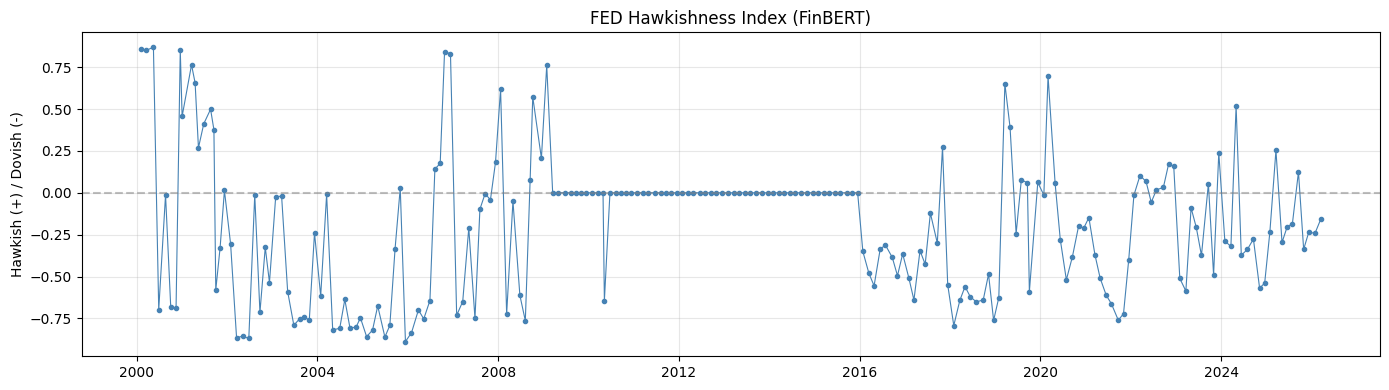


Validación del Hawkish Index vs contexto histórico:
  2009-2013: Valores negativos (dovish) — era QE con tasas en cero.
  2017-2018: Territorio positivo (hawkish) — la FED estaba subiendo tasas.
  2020:      Caída abrupta a dovish — recorte de emergencia por COVID.
  2022-2024: Mayor varianza y señales hawkish — ciclo de tightening más agresivo en décadas.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
sentiment_model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

import re

def split_into_chunks(text, max_chars=450):
    sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z])', text)
    chunks, current = [], ""
    for s in sentences:
        if len(current) + len(s) > max_chars and current:
            chunks.append(current.strip())
            current = s
        else:
            current = current + " " + s if current else s
    if current.strip():
        chunks.append(current.strip())
    return [c for c in chunks if len(c) > 80]

def extract_finbert_sentiment(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.33, 0.33, 0.33, 0.0
    chunks = split_into_chunks(text, max_chars=450)
    if not chunks:
        chunks = [text[:500]]
    all_scores = []
    for chunk in chunks:
        inputs = tokenizer(chunk, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            outputs = sentiment_model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze().tolist()
        pos, neg, neu = probs[0], probs[1], probs[2]
        extremeness = abs(neg - pos)
        all_scores.append((pos, neg, neu, extremeness))
    total_weight = sum(s[3] + 0.01 for s in all_scores)
    pos_agg = sum(s[0] * (s[3] + 0.01) for s in all_scores) / total_weight
    neg_agg = sum(s[1] * (s[3] + 0.01) for s in all_scores) / total_weight
    neu_agg = sum(s[2] * (s[3] + 0.01) for s in all_scores) / total_weight
    return pos_agg, neg_agg, neu_agg, neg_agg - pos_agg

nlp_cols = ["finbert_positive", "finbert_negative", "finbert_neutral", "hawkish_index"]
df_fed = df_fed.drop(columns=[c for c in nlp_cols if c in df_fed.columns], errors="ignore")

print("Analizando statements de la FED con FinBERT...")
sentiments = []
for _, row in df_fed.iterrows():
    p, n, ne, h = extract_finbert_sentiment(row["content"])
    sentiments.append({"finbert_positive": p, "finbert_negative": n,
                       "finbert_neutral": ne, "hawkish_index": h})

df_fed[nlp_cols] = pd.DataFrame(sentiments, index=df_fed.index)
print(f"NLP completado. {len(df_fed)} statements analizados.")

plt.figure(figsize=(14, 4))
plt.plot(df_fed["date"], df_fed["hawkish_index"], marker="o", markersize=3, linewidth=0.8, color="steelblue")
plt.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
plt.title("FED Hawkishness Index (FinBERT)"); plt.ylabel("Hawkish (+) / Dovish (-)")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("\nValidación del Hawkish Index vs contexto histórico:")
print("  2009-2013: Valores negativos (dovish) — era QE con tasas en cero.")
print("  2017-2018: Territorio positivo (hawkish) — la FED estaba subiendo tasas.")
print("  2020:      Caída abrupta a dovish — recorte de emergencia por COVID.")
print("  2022-2024: Mayor varianza y señales hawkish — ciclo de tightening más agresivo en décadas.")

Nuevas features NLP derivadas:


,date,hawkish_index,hawkish_delta,hawkish_ma3,hawkish_vol3,hawkish_streak
198,2024-06-12,-0.372771,-0.891373,-0.058161,0.500180,-1
199,2024-07-31,-0.338008,0.034763,-0.064059,0.504899,-2
200,2024-09-18,-0.275974,0.062034,-0.328918,0.049034,-3
201,2024-11-07,-0.569708,-0.293734,-0.394564,0.154819,-4
202,2024-12-18,-0.538158,0.031550,-0.461280,0.161253,-5
203,2025-01-29,-0.233540,0.304618,-0.447136,0.185650,-6
204,2025-03-19,0.253146,0.486687,-0.172851,0.399128,1
205,2025-05-07,-0.296335,-0.549482,-0.092243,0.300759,-1
206,2025-06-18,-0.202616,0.093719,-0.081935,0.293948,-2
207,2025-07-30,-0.184496,0.018120,-0.227816,0.060027,-3


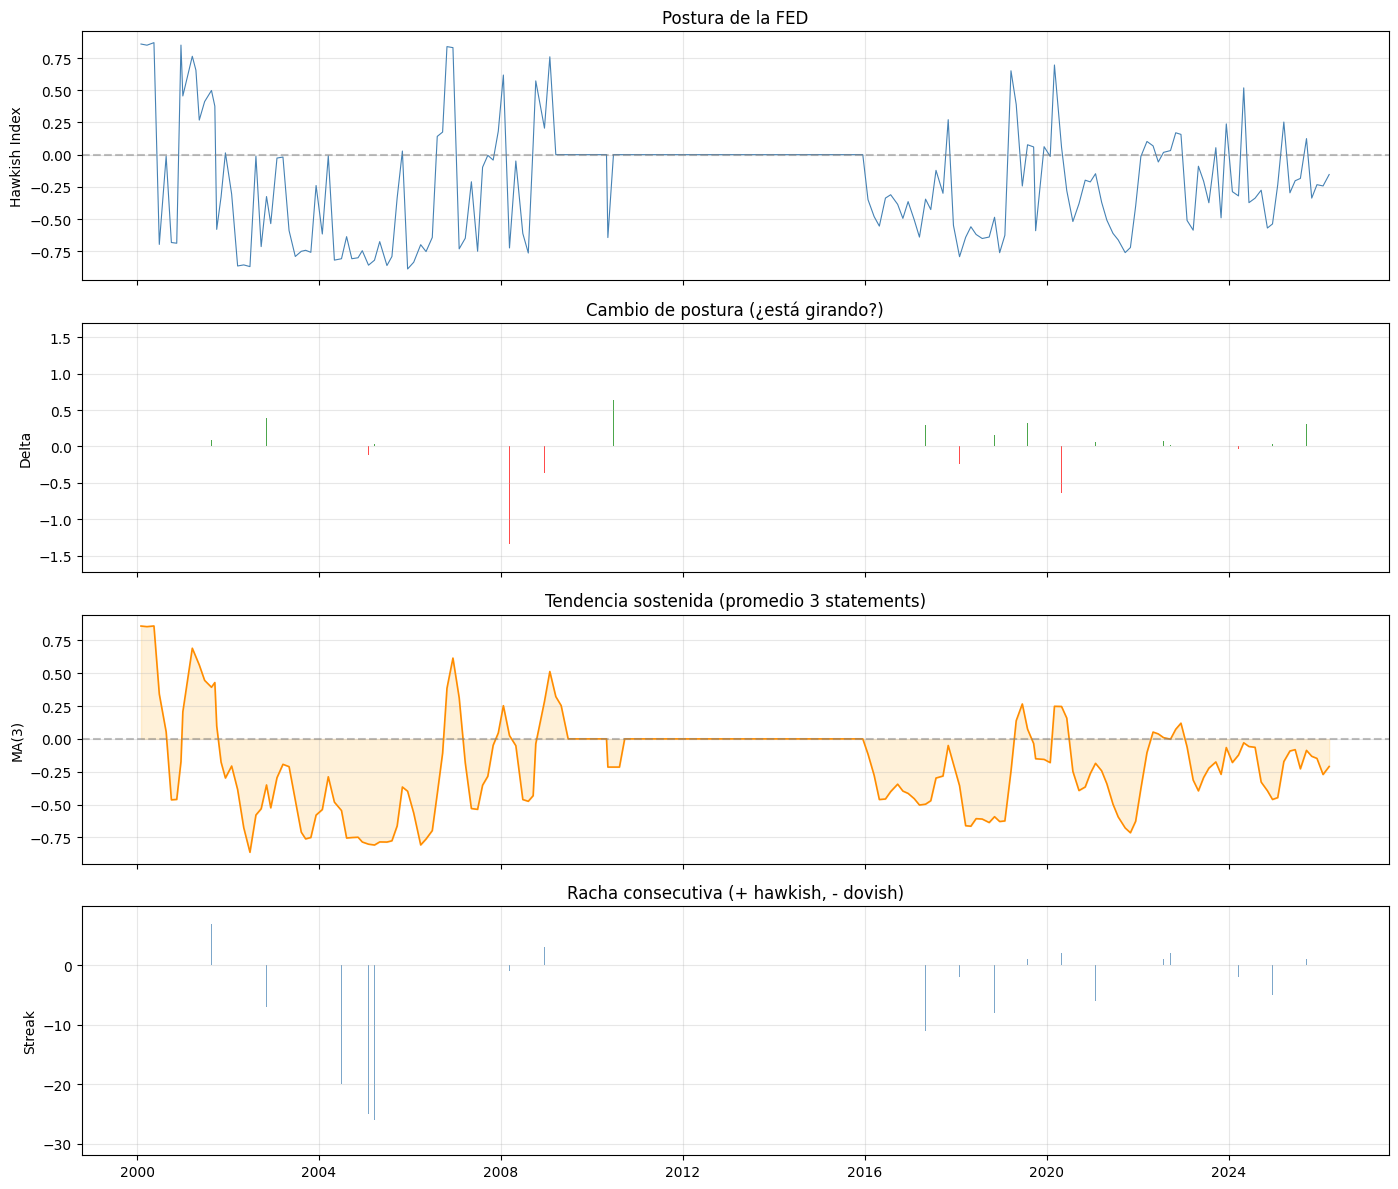

In [ ]:
# === FEATURES DERIVADAS DE LA POSICIÓN DE LA FED ===
# El mercado reacciona más al CAMBIO de postura que a la postura en sí.

# 1. Delta del hawkish index: ¿la FED se está volviendo más o menos hawkish?
#    Positivo = girando hawkish, Negativo = girando dovish
df_fed["hawkish_delta"] = df_fed["hawkish_index"].diff()

# 2. Persistencia: promedio móvil de 3 statements (~4-5 meses)
#    Captura si la postura se ha mantenido estable
df_fed["hawkish_ma3"] = df_fed["hawkish_index"].rolling(3, min_periods=1).mean()

# 3. Volatilidad de la postura: ¿la FED ha sido consistente o errática?
#    Alta vol = incertidumbre sobre la dirección monetaria
df_fed["hawkish_vol3"] = df_fed["hawkish_index"].rolling(3, min_periods=1).std().fillna(0)

# 4. Streak: ¿cuántos statements consecutivos en la misma dirección?
#    Positivo = racha hawkish, Negativo = racha dovish
def compute_streak(series):
    streaks = []
    current = 0
    for val in series:
        if val > 0:
            current = current + 1 if current > 0 else 1
        elif val < 0:
            current = current - 1 if current < 0 else -1
        else:
            current = 0
        streaks.append(current)
    return streaks

df_fed["hawkish_streak"] = compute_streak(df_fed["hawkish_index"])

# Verificar
print("Nuevas features NLP derivadas:")
display(df_fed[["date", "hawkish_index", "hawkish_delta", "hawkish_ma3",
                "hawkish_vol3", "hawkish_streak"]].tail(15))

# Visualizar
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df_fed["date"], df_fed["hawkish_index"], color="steelblue", linewidth=0.8)
axes[0].set_ylabel("Hawkish Index"); axes[0].set_title("Postura de la FED")
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5)

axes[1].bar(df_fed["date"], df_fed["hawkish_delta"], color=["green" if x > 0 else "red" for x in df_fed["hawkish_delta"]], alpha=0.7)
axes[1].set_ylabel("Delta"); axes[1].set_title("Cambio de postura (¿está girando?)")

axes[2].plot(df_fed["date"], df_fed["hawkish_ma3"], color="darkorange", linewidth=1.2)
axes[2].fill_between(df_fed["date"], df_fed["hawkish_ma3"], 0, alpha=0.15, color="orange")
axes[2].set_ylabel("MA(3)"); axes[2].set_title("Tendencia sostenida (promedio 3 statements)")
axes[2].axhline(0, color="gray", linestyle="--", alpha=0.5)

axes[3].bar(df_fed["date"], df_fed["hawkish_streak"], color="steelblue", alpha=0.7)
axes[3].set_ylabel("Streak"); axes[3].set_title("Racha consecutiva (+ hawkish, - dovish)")

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 4. Datos de Mercado (Yahoo Finance)
**Tickers (sectores):**
- `AMD` - Semiconductores / Tecnología
- `GOOGL` - Big Tech / Comunicaciones
- `AGG` - Bonos Agregados (ETF renta fija)
- `XOM` - Energía / Petróleo
- `JNJ` - Salud / Farmacéutica
- `WMT` - Consumo básico / Retail
- `CM` - Banca canadiense
- `DUK` - Utilities / Energía eléctrica
- `BNS` - Banca canadiense


In [ ]:
import yfinance as yf

TICKERS = ["AMD", "GOOGL", "AGG", "XOM", "JNJ", "WMT", "CM", "DUK", "BNS"]
START_DATE, END_DATE = "2003-01-01", "2024-12-31"

ticker_info = {
    "AMD":   "Semiconductores / Tecnología",
    "GOOGL": "Big Tech / Comunicaciones",
    "AGG":   "Bonos Agregados (ETF Renta Fija)",
    "XOM":   "Energía / Petróleo",
    "JNJ":   "Salud / Farmacéutica",
    "WMT":   "Consumo Básico / Retail",
    "CM":    "Banca Canadiense",
    "DUK":   "Utilities / Energía Eléctrica",
    "BNS":   "Banca Canadiense",
}

print(f"Descargando {len(TICKERS)} activos ({START_DATE} → {END_DATE})...")
print("=" * 70)

frames = {}
for t in TICKERS:
    try:
        raw = yf.download(t, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        if not raw.empty:
            frames[t] = raw["Close"]
            print(f"  ✓ {t} ({ticker_info[t]}): {len(raw)} días, "
                  f"{raw.index[0].strftime('%Y-%m-%d')} → {raw.index[-1].strftime('%Y-%m-%d')}")
        else:
            print(f"  ✗ {t}: sin datos")
    except Exception as e:
        print(f"  ✗ {t}: ERROR - {e}")

df_prices = pd.DataFrame(frames)
df_prices.index.name = "date"
df_prices = df_prices.reset_index()
df_prices["date"] = pd.to_datetime(df_prices["date"])
df_prices = df_prices.sort_values("date")

print(f"\n✅ {len(df_prices)} días descargados")
print(f"\nNaN por ticker:")
print(df_prices[TICKERS].isna().sum())


Descargando 9 activos (2003-01-01 → 2024-12-31)...
  ✓ AMD (Semiconductores / Tecnología): 5536 días, 2003-01-02 → 2024-12-30
  ✓ GOOGL (Big Tech / Comunicaciones): 5126 días, 2004-08-19 → 2024-12-30
  ✓ AGG (Bonos Agregados (ETF Renta Fija)): 5350 días, 2003-09-29 → 2024-12-30
  ✓ XOM (Energía / Petróleo): 5536 días, 2003-01-02 → 2024-12-30
  ✓ JNJ (Salud / Farmacéutica): 5536 días, 2003-01-02 → 2024-12-30
  ✓ WMT (Consumo Básico / Retail): 5536 días, 2003-01-02 → 2024-12-30
  ✓ CM (Banca Canadiense): 5536 días, 2003-01-02 → 2024-12-30
  ✓ DUK (Utilities / Energía Eléctrica): 5536 días, 2003-01-02 → 2024-12-30
  ✓ BNS (Banca Canadiense): 5536 días, 2003-01-02 → 2024-12-30

✅ 5536 días descargados

NaN por ticker:
AMD        0
GOOGL    410
AGG      186
XOM        0
JNJ        0
WMT        0
CM         0
DUK        0
BNS        0
dtype: int64


### 5. Variables Macroeconómicas (FRED)

El Hawkish Index captura la *percepción* de la FED, pero el modelo necesita cruzarla con la *realidad cuantitativa* del ciclo económico. Descargamos 13 series de **FRED** vía `pandas_datareader` y las transformamos en 22 features organizadas en tres categorías:

**Niveles (9 vars):** Estado actual del ciclo.
- `UNRATE` (desempleo), `FEDFUNDS` (tasa de política monetaria), `T10Y2Y` (spread de curva 10Y-2Y, predictor de recesión), `DGS10` (rendimiento 10Y, costo de capital), `BAA10Y` (spread corporativo, estrés financiero), `VIXCLS` (volatilidad implícita), `UMCSENT` (sentimiento del consumidor), `DCOILWTICO` (petróleo WTI), `ICSA` (solicitudes iniciales de desempleo).

**Deltas (9 vars):** Dirección del cambio — tan importante como el nivel. Desempleo al 5% bajando (recuperación) ≠ subiendo (deterioro). Calculados como `diff()` mensual de cada variable en nivel.

**Tasas de cambio (4 vars):** Variables que ya son derivadas. `Inflation` (pct_change del CPI), `INDPRO_Growth` (producción industrial), `M2_Growth` (liquidez monetaria), `DGORDER_Growth` (pedidos de bienes durables).

Se alinean a frecuencia mensual (`ME`) y se unen al dataset principal.

In [ ]:
import pandas_datareader.data as web

macro_start = datetime.datetime(2002, 1, 1)
macro_end = datetime.datetime(2024, 12, 31)

fred_series = [
    "UNRATE", "CPIAUCSL", "INDPRO", "UMCSENT", "DGORDER",
    "ICSA", "FEDFUNDS", "T10Y2Y", "DGS10",
    "BAA10Y", "VIXCLS", "M2SL", "DCOILWTICO"
]
df_macro = web.DataReader(fred_series, "fred", macro_start, macro_end)

# Tasas de cambio
df_macro["Inflation"] = df_macro["CPIAUCSL"].pct_change()
df_macro["INDPRO_Growth"] = df_macro["INDPRO"].pct_change()
df_macro["M2_Growth"] = df_macro["M2SL"].pct_change()
df_macro["DGORDER_Growth"] = df_macro["DGORDER"].pct_change()
df_macro["ICSA"] = df_macro["ICSA"].resample("ME").mean()

df_macro_monthly = df_macro.resample("ME").last()

# Deltas mensuales
#modelo v1 & v2
level_vars_ini = ["UNRATE", "FEDFUNDS", "T10Y2Y", "DGS10", "BAA10Y",
              "VIXCLS", "UMCSENT", "DCOILWTICO", "ICSA"]
# modelo v3
level_vars = ["UNRATE","FEDFUNDS", "T10Y2Y", "DGS10",
              #"BAA10Y",
              "VIXCLS","UMCSENT", "DCOILWTICO", "ICSA"]

delta_vars= ["d_UNRATE", "FEDFUNDS",
              "d_T10Y2Y", "d_DGS10",
              "d_BAA10Y","d_VIXCLS",
              "d_UMCSENT",
              #"DCOILWTICO",
             "ICSA"]

for v in level_vars_ini:
    df_macro_monthly[f"d_{v}"] = df_macro_monthly[v].diff()

macro_levels = list(level_vars)
macro_deltas = list(delta_vars)

#modelo v1 & v2
#macro_deltas = [f"d_{v}" for v in level_vars]
macro_rates = ["Inflation", "INDPRO_Growth", "M2_Growth", "DGORDER_Growth"]

macro_features = macro_levels + macro_deltas + macro_rates

df_macro_final = df_macro_monthly[macro_features].ffill().dropna()
print(f"Macro: {len(macro_features)} vars ({len(macro_levels)} niveles + {len(macro_deltas)} deltas + {len(macro_rates)} tasas)")

Macro: 20 vars (8 niveles + 8 deltas + 4 tasas)


### 6. Alineación Temporal y Construcción del Dataset (limpieza de datos)
Tenemos una brecha entre la data proveniente de Yahoo Finance y la data proveniente de los statements de la FED, ya que los mercados operan diariamente, pero la FED se reúne aproximadamente 8 veces al año. Para solucionar esta diferencia de frecuencias:
1. Realizamos un *Forward Fill Lógico* (`merge_asof`): El mercado asume la información del "último comunicado disponible" hasta que se publique uno nuevo.
2. Convertimos los datos diarios a una **frecuencia mensual** para reducir el ruido, calculando el retorno porcentual mensual de cada activo. Esta es la variable objetivo (Target) para la optimización de Markowitz.

In [ ]:
print("Alineando temporalmente los datos de Mercado y NLP...")
# 1. Extraemos solo los precios de cierre
df_prices_sorted = df_prices.sort_values("date").set_index("date")
df_monthly_prices = df_prices_sorted.resample("ME").last()
return_cols = [f"{t}_Return" for t in TICKERS]
for t in TICKERS:
    df_monthly_prices[f"{t}_Return"] = df_monthly_prices[t].pct_change()

# 2. Forward Fill NLP

#primera version del modelo con 4NLP
#nlp_features = ["fed_hawkish", "fed_dovish", "fed_neutral", "hawkish_index"]

#Segunda version del modelo, agregando delta a NLP, en total 8NLP
#nlp_features = ["finbert_positive", "finbert_negative", "finbert_neutral",
#                "hawkish_index", "hawkish_delta", "hawkish_ma3",
#                "hawkish_vol3", "hawkish_streak"]

#3 version del modelo dejando unicamente las variables NLP importantes parqa no meter ruido con las otras
nlp_features = ["finbert_positive", "finbert_negative", "hawkish_index"]

# 3. Aseguramos de que las fechas de la FED estén en formato datetime
df_fed_sorted = df_fed[["date"] + nlp_features].sort_values("date")
monthly_df = pd.DataFrame({"date": df_monthly_prices.index.to_series().reset_index(drop=True)})

# 4. Agrupación a Frecuencia Mensual (Resampling)
monthly_nlp = pd.merge_asof(monthly_df, df_fed_sorted, on="date", direction="backward")

# 5. Limpieza y Manejo de NaNs
#limpieza modelo v1 y v2
for col in ["finbert_positive", "finbert_negative"]:
    monthly_nlp[col] = monthly_nlp[col].fillna(1/3)
for col in ["hawkish_index"]:
    monthly_nlp[col] = monthly_nlp[col].fillna(0.0)

# limpieza modelo v3
#monthly_nlp["fed_hawkish"] = monthly_nlp["fed_hawkish"].fillna(1/3)
#monthly_nlp["hawkish_index"] = monthly_nlp["hawkish_index"].fillna(0.0)

df_combined = df_monthly_prices.copy()
df_combined = df_combined.join(monthly_nlp[nlp_features], how="left")
df_combined = df_combined.join(df_macro_final, how="left")
df_combined = df_combined.dropna(subset=return_cols, how="all").ffill().dropna()
df_combined = df_combined[df_combined.index >= "2003-06-01"]

print(f"Dataset: {len(df_combined)} meses | {len(return_cols)} ret + {len(nlp_features)} NLP + {len(macro_features)} macro = {len(return_cols)+len(nlp_features)+len(macro_features)} features")

Alineando temporalmente los datos de Mercado y NLP...
Dataset: 0 meses | 9 ret + 3 NLP + 20 macro = 32 features


In [ ]:
df_prices_sorted = df_prices.sort_values("date").set_index("date")
df_monthly_prices = df_prices_sorted.resample("ME").last()

return_cols = [f"{t}_Return" for t in TICKERS]
for t in TICKERS:
    df_monthly_prices[f"{t}_Return"] = df_monthly_prices[t].pct_change()

nlp_features = ["finbert_positive", "finbert_negative", "finbert_neutral", "hawkish_index"]
df_fed_sorted = df_fed[["date"] + nlp_features].sort_values("date")
monthly_df = pd.DataFrame({"date": df_monthly_prices.index.to_series().reset_index(drop=True)})
monthly_nlp = pd.merge_asof(monthly_df, df_fed_sorted, on="date", direction="backward")

for col in ["finbert_positive", "finbert_negative", "finbert_neutral"]:
    monthly_nlp[col] = monthly_nlp[col].fillna(1/3)
monthly_nlp["hawkish_index"] = monthly_nlp["hawkish_index"].fillna(0.0)
monthly_nlp.set_index("date", inplace=True)

# Join paso a paso con diagnóstico
df_combined = df_monthly_prices.copy()
print(f"1. Después de copiar precios: {len(df_combined)} filas")

df_combined = df_combined.join(monthly_nlp[nlp_features], how="left")
print(f"2. Después de join NLP: {len(df_combined)} filas | NaN NLP: {df_combined[nlp_features].isna().sum().sum()}")

df_combined = df_combined.join(df_macro_final, how="left")
print(f"3. Después de join Macro: {len(df_combined)} filas | NaN Macro: {df_combined[macro_features].isna().sum().sum()}")

# Paso crítico: ver qué elimina cada operación
before_drop1 = len(df_combined)
df_combined = df_combined.dropna(subset=return_cols, how="all")
print(f"4. Después de dropna(returns): {len(df_combined)} filas (eliminó {before_drop1 - len(df_combined)})")

df_combined = df_combined.ffill()
remaining_na = df_combined.isna().sum()
print(f"5. Después de ffill, NaN restantes:")
print(remaining_na[remaining_na > 0])

df_combined = df_combined.dropna()
print(f"6. Después de dropna final: {len(df_combined)} filas")

df_combined = df_combined[df_combined.index >= "2003-06-01"]
print(f"7. Después de filtro 2003+: {len(df_combined)} filas")

print(f"\n✅ Dataset: {len(df_combined)} meses")

1. Después de copiar precios: 264 filas
2. Después de join NLP: 264 filas | NaN NLP: 0
3. Después de join Macro: 264 filas | NaN Macro: 0
4. Después de dropna(returns): 263 filas (eliminó 1)
5. Después de ffill, NaN restantes:
GOOGL           18
AGG              7
GOOGL_Return    19
AGG_Return       8
dtype: int64
6. Después de dropna final: 244 filas
7. Después de filtro 2003+: 244 filas

✅ Dataset: 244 meses


### 7. Normalización, Ventanas Deslizantes y Split Cronológico (Feature Scaling)
Las redes neuronales (como el LSTM) son muy sensibles a la escala de los datos. Variables con magnitudes muy distintas pueden causar explosión de gradientes o evitar que el modelo converja.

En este paso aplicamos `StandardScaler` a nuestros datos cuantitativos  y a nuestras métricas cualitativas. Esto nos asegura que todas las características compartan una escala estandarizada con media de 0 y desviación estándar de 1 para poder hacer un entrenamiento estable

Los modelos LSTM (Long Short-Term Memory) están diseñados para aprender de secuencias temporales. Transformamos nuestro dataset tabular en **Tensores 3D** con la forma `(Muestras, Pasos de Tiempo, Características)`.
Utilizamos una ventana temporal de 6 meses: el modelo observará los datos del semestre pasado para predecir los retornos del mes siguiente ($t+1$).

In [ ]:
# 1. Unimos todas las características numéricas que irán al LSTM (X)
features_to_scale = return_cols + nlp_features + macro_features

# 2. Inicializamos el Scaler y transformamos los datos
scaler = StandardScaler()
df_scaled = df_combined.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_combined[features_to_scale])

# 3. Definimos el tamaño de la ventana
n_features = len(features_to_scale)
n_activos = len(return_cols)
seq_length = 6

# 4. Unimos todo en una sola matriz (Retornos + Sentimientos + Embeddings)
feature_matrix = df_scaled[features_to_scale].values

# 5. Listas para guardar las secuencias (X) y los objetivos (y)
X, y, target_dates = [], [], []

# 6. Bucle de ventana deslizante
for i in range(len(feature_matrix) - seq_length):
    # X: Tomamos 'seq_length' meses consecutivos
    X.append(feature_matrix[i : i + seq_length])
    # y: Tomamos los retornos del mes posterior a la ventana
    # Solo tomamos las primeras columnas (los retornos)
    y.append(feature_matrix[i + seq_length, :n_activos])
    target_dates.append(df_scaled.index[i + seq_length])


# **FASE 3**
# **Diseño e implementación experimental**
---

## **1. Particion del conjunto de datos**
---


En problemas de series temporales financieras, la partición aleatoria (random split) está estrictamente prohibida porque introduce data leakage temporal: el modelo observaría información futura para predecir el pasado, inflando artificialmente las métricas. Se utiliza un split cronológico secuencial que respeta la causalidad del mercado.
Proporciones seleccionadas: 70% Train / 15% Validation / 15% Test

**Train (70%)**: Período más antiguo. Proporciona suficiente historia para que el LSTM aprenda patrones entre el sentimiento de la FED y los retornos de mercado.
**Validation (15%)**: Período intermedio. Se utiliza para selección de hiperparámetros (grid search) y early stopping, evitando sobreajuste al conjunto de entrenamiento.
**Test (15%)**: Período más reciente (Oct 2023 – Mar 2024). Simula un escenario de inversión real donde el modelo predice meses que nunca ha visto.

In [ ]:

# 5. Convertir a arrays de NumPy (Formato oficial para PyTorch/TensorFlow)
X, y, target_dates = np.array(X), np.array(y), np.array(target_dates)

total = len(X)
t_end = int(total * 0.70)
v_end = t_end + int(total * 0.15)

X_train, y_train = X[:t_end], y[:t_end]
X_val, y_val = X[t_end:v_end], y[t_end:v_end]
X_test, y_test = X[v_end:], y[v_end:]
dates_train = target_dates[:t_end]
dates_val = target_dates[t_end:v_end]
dates_test = target_dates[v_end:]

print(f"Features: {n_features} | Ventana: {seq_length} meses")
print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Features: 33 | Ventana: 6 meses
Train: 166 | Val: 35 | Test: 37


## **2. Selección y diseño de modelos**
---



## Modelo LSTM Multi-Output Global (FinancialLSTM_V2)

**Arquitectura:**
`LSTM(stacked) → LayerNorm → Dropout → FC(fc_hidden) → ReLU → Dropout → FC(9)`

Se usa **LayerNorm** en vez de BatchNorm porque con batches pequeños (~16–32 muestras) BatchNorm produce estimaciones de media/varianza ruidosas. LayerNorm normaliza por muestra individual. Se agregó una **capa FC intermedia** para darle más capacidad al mapping estado-macro → retornos sectoriales.

**¿Por qué un modelo global en vez de uno por activo?**
- La tesis del proyecto es sobre **rotación sectorial**: las condiciones macro son comunes a todos los activos, lo que cambia es cómo cada sector responde. Un modelo global captura esa dinámica cruzada.
- Con ~170 muestras de train, un modelo por activo multiplicaría el riesgo de overfitting por 9. El modelo global comparte parámetros, actuando como regularización implícita.
- Markowitz necesita predicciones **coherentes** entre activos. Un modelo global produce retornos esperados desde la misma representación latente del estado macro.

**Grid Search — 96 configuraciones:**
- `hidden_size` ∈ {32, 64, 128}, `num_layers` ∈ {1, 2}, `lr` ∈ {1e-3, 5e-4}
- `dropout` ∈ {0.15, 0.25}, `fc_hidden` ∈ {16, 32}, `batch_size` ∈ {16, 32}

**Loss function:** MSELoss — adecuada para output multi-activo con retornos estandarizados.

---

### Técnicas de regularización

- **Early Stopping** (patience=8/15): Detiene el entrenamiento cuando la pérdida de validación deja de mejorar.
- **Dropout** (0.15–0.25): Regularización estocástica. Se aplica dropout reducido (×0.5) antes de la capa final.
- **Gradient Clipping** (max_norm=1.0): Previene explosión de gradientes, frecuente en LSTM con series financieras volátiles.
- **ReduceLROnPlateau**: Reduce el learning rate automáticamente al estancarse, permitiendo convergencia más fina.
- **Weight Decay** (L2=1e-5): Penaliza pesos grandes en Adam.
- **LayerNorm**: Estabiliza activaciones intermedias sin depender del tamaño del batch.

---

### Justificación frente a alternativas

**¿Por qué no Transformer?** Con ~250 meses y 35 features, un Transformer con atención completa sería propenso a sobreajuste. El LSTM es más eficiente con datos limitados. Además, ya aprovechamos un Transformer (FinBERT) en la extracción NLP.

**¿Por qué no modelos clásicos (ARIMA, VAR)?** No capturan relaciones no lineales entre 35 features heterogéneas (macro + NLP + retornos) ni interacciones condicionales al régimen económico.

**¿Por qué no GRU?** Funcionalmente similar pero con menos compuertas. Se prefirió LSTM por su mayor capacidad para dependencias largas, relevante dado que los efectos de política monetaria tardan trimestres en materializarse.

**¿Por qué no un modelo por activo (V1)?** Se probó un enfoque con un LSTM independiente por activo (216 configs × 9 activos = 1,944 modelos). Produjo R² negativos en test y directional accuracy de 33% en varios activos — peor que el azar. El modelo global V2 regulariza implícitamente al forzar patrones consistentes entre activos.

# **FASE 4**

# **Entrenamiento y Validación**
---

## ¿Cómo funciona el LSTM? — Intuición Visual

El LSTM procesa cada mes de la ventana de 6 meses secuencialmente. En cada paso, decide qué recordar, qué olvidar y qué comunicar usando tres compuertas:

LSTM — Un Paso Temporal (1 mes)

## ¿Cómo funciona el LSTM? — Intuición Visual

El LSTM procesa cada mes de la ventana de 6 meses secuencialmente. En cada paso, decide qué recordar, qué olvidar y qué comunicar usando tres compuertas:

```
                            LSTM — Un Paso Temporal (1 mes)
    
    INPUTS:
    ┌────────────────────────────┐    ┌──────────────────────────────┐
    │  x(t) = Features del mes   │    │  h(t-1) = Opinión del mes    │
    │  - 9 retornos de activos   │    │           anterior           │
    │  - 8 NLP (hawkish index)   │    │                              │
    │  - 22 variables macro      │    │                              │
    └─────────────┬──────────────┘    └──────────────┬───────────────┘
                  └──────────┬───────────────────────┘
                             ▼
    ╔═══════════════════════════════════════════════════════════════════╗
    ║                                                                   ║
    ║  ┌──────────────────┐  ┌──────────────────┐  ┌────────────────┐   ║
    ║  │  FORGET GATE     │  │  INPUT GATE      │  │  OUTPUT GATE   │   ║
    ║  │                  │  │                  │  │                │   ║
    ║  │ "¿Qué olvido     │  │ "¿Qué anoto      │  │ "¿Qué comunico │   ║
    ║  │  del pasado?"    │  │  de nuevo?"      │  │  como lectura?"│   ║
    ║  │                  │  │                  │  │                │   ║
    ║  │ Ej: "Inflación   │  │ Ej: "La curva    │  │ Ej: "Tech va   │   ║
    ║  │ de hace 6 meses  │  │ se invirtió →    │  │ a sufrir,      │   ║
    ║  │ ya no importa"   │  │ ¡guardar esto!"  │  │ defensivos     │   ║
    ║  │                  │  │                  │  │ van a subir"   │   ║
    ║  │  σ → [0, 1]      │  │  σ → [0, 1]      │  │  σ → [0, 1]    │   ║
    ║  └────────┬─────────┘  └────────┬─────────┘  └────────┬───────┘   ║
    ║           │                     │                     │           ║
    ╚═══════════╪═════════════════════╪═════════════════════╪═══════════╝
                │                     │                     │
                ▼                     ▼                     │
    ┌───────────────────────────────────────────┐           │
    │  CELL STATE (Memoria de largo plazo)      │           │
    │                                           │           │
    │  Memoria anterior × forget_gate           │           │
    │         (borra lo irrelevante)            │           │
    │              │                            │           │
    │              ▼                            │           │
    │  + input_gate × nueva_info                │           │
    │    (agrega lo relevante)                  │           │
    │              │                            │           │
    │              ▼                            │           │
    │         C(t) = Memoria actualizada ───────┼───────────┤
    │                                           │           │
    └───────────────────────────────────────────┘           │
                                                            ▼
    OUTPUTS:                                     ┌──────────────────┐
    ┌──────────────────────────┐                 │  h(t) = Opinión  │
    │ C(t) → pasa al mes       │                 │  de este mes     │
    │        siguiente como    │                 │  (filtrada por   │
    │        memoria           │                 │   output gate)   │
    └──────────────────────────┘                 └────────┬─────────┘
                                                          │
                                                          ▼
                                               Al mes siguiente
                                               o si es el MES 6:
                                               → LayerNorm → FC(9)
                                               → 9 retornos predichos
```

### Flujo completo de MacroPulse
gate 1: Cuando la situación macro es estable. Si la FED lleva 3 meses con el mismo tono y las tasas no se mueven, la compuerta dice "lo que aprendí los meses anteriores sigue siendo válido, no borres nada."

gate 2:Si el hawkish_index pasa de -0.3 a +0.5 en un solo mes (la FED pivotea de dovish a hawkish), la input gate reconoce "esto es nuevo y relevante, guárdalo." También cuando d_DGS10 tiene un movimiento grande — la dirección de las tasas cambió y eso afecta todo.

gate 3: Cuando la información almacenada es directamente relevante para predecir retornos. Si la memoria dice "la curva lleva 4 meses invertida" y el modelo aprendió que eso precede caídas en bancos, la output gate abre esa señal para que llegue a la capa FC y afecte la predicción de CM y BNS.

### Flujo completo de MacroPulse

| Mes 1 | Mes 2 | Mes 3 | Mes 4 | Mes 5 | Mes 6 |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 35 features | 35 features | 35 features | 35 features | 35 features | 35 features |
| 9 retornos | 9 retornos | 9 retornos | 9 retornos | 9 retornos | 9 retornos |
| 8 NLP | 8 NLP | 8 NLP | 8 NLP | 8 NLP | 8 NLP |
| 22 macro | 22 macro | 22 macro | 22 macro | 22 macro | 22 macro |
| ↓ | ↓ | ↓ | ↓ | ↓ | ↓ |
| **LSTM Cell** → | **LSTM Cell** → | **LSTM Cell** → | **LSTM Cell** → | **LSTM Cell** → | **LSTM Cell** |

El LSTM acumula contexto de 6 meses en su memoria (Cell State). Al final del mes 6, su "opinión" pasa a la cabeza de predicción:

| Capa | Función |
|:---|:---|
| **LSTM output (mes 6)** | Resumen acumulado del semestre |
| ↓ LayerNorm | Estabiliza la distribución de activaciones |
| ↓ Dropout | Regularización estocástica |
| ↓ FC(32) + ReLU | Mapea estado macro → espacio sectorial |
| ↓ FC(9) | Proyecta a 9 retornos predichos |

**Ejemplo de lo que aprende:**
> *"Curva invertida hace 3 meses + hawkish index subiendo + VIX alto → tech (AMD, GOOGL) baja, defensivos (DUK, AGG, JNJ) suben"*

| Output: 9 retornos predichos |
|:---:|
| AMD · GOOGL · AGG |
| XOM · JNJ · WMT |
| CM · DUK · BNS |

La clave del LSTM frente a una red neuronal estándar es el **Cell State** (memoria): la información fluye a través de los 6 meses sin degradarse, permitiendo que el modelo recuerde que **la curva se invirtió hace 4 meses y que eso históricamente precede caídas en bancos (CM, BNS) y subidas en utilities (DUK, AGG)**.

### 8. Modelo LSTM Multi-Output (V2 Global)

Un solo modelo predice los 9 activos simultáneamente, capturando la rotación sectorial.
Arquitectura: `LSTM(stacked) → LayerNorm → Dropout → FC → ReLU → Dropout → FC(9)`

In [ ]:
class FinancialLSTM_V2(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size,
                 dropout=0.2, fc_hidden=32):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                           num_layers=num_layers,
                           dropout=dropout if num_layers > 1 else 0.0,
                           batch_first=True)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(fc_hidden, output_size)
        )

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.head(out[:, -1, :])

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            total_loss += criterion(preds, yb).item()
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())
    return (total_loss / len(loader),
            np.concatenate(all_preds, axis=0),
            np.concatenate(all_targets, axis=0))

### 9. Grid Search de Hiperparámetros

In [ ]:
def run_grid_search(X_tr, y_tr, X_v, y_v, in_sz, out_sz, epochs=50, patience=8):
    pg = {"hidden_size": [32, 64, 128], "num_layers": [1, 2],
          "lr": [1e-3, 5e-4], "dropout": [0.15, 0.25],
          "fc_hidden": [16, 32], "batch_size": [16, 32]}
    keys = list(pg.keys())
    combos = list(itertools.product(*pg.values()))
    print(f"Grid Search: {len(combos)} combinaciones\n")

    Xt = torch.tensor(X_tr, dtype=torch.float32)
    yt = torch.tensor(y_tr, dtype=torch.float32)
    Xv = torch.tensor(X_v, dtype=torch.float32)
    yv = torch.tensor(y_v, dtype=torch.float32)

    results, bvl, bp, bs = [], float("inf"), None, None
    for idx, combo in enumerate(combos, 1):
        p = dict(zip(keys, combo))
        print(f"[{idx:3d}/{len(combos)}] {p}", end="")
        tld = DataLoader(TensorDataset(Xt, yt), batch_size=p["batch_size"], shuffle=False)
        vld = DataLoader(TensorDataset(Xv, yv), batch_size=p["batch_size"], shuffle=False)
        m = FinancialLSTM_V2(in_sz, p["hidden_size"], p["num_layers"],
                              out_sz, p["dropout"], p["fc_hidden"]).to(device)
        opt = torch.optim.Adam(m.parameters(), lr=p["lr"], weight_decay=1e-5)
        crit = nn.MSELoss()
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4)
        bel, ni, bst = float("inf"), 0, None
        for ep in range(epochs):
            train_epoch(m, tld, opt, crit)
            vl, _, _ = evaluate(m, vld, crit)
            sch.step(vl)
            if vl < bel:
                bel = vl; bst = {k: v.clone() for k, v in m.state_dict().items()}; ni = 0
            else:
                ni += 1
                if ni >= patience: break
        print(f" -> Val: {bel:.6f}")
        results.append({**p, "val_loss": bel})
        if bel < bvl: bvl, bp, bs = bel, p, bst
    print(f"\nMejor: {bp} | Val: {bvl:.6f}")
    return bp, bs, results

INPUT_SIZE = X_train.shape[2]
OUTPUT_SIZE = len(TICKERS)

best_params, best_state, gs_results = run_grid_search(
    X_train, y_train, X_val, y_val, INPUT_SIZE, OUTPUT_SIZE)
display(pd.DataFrame(gs_results).sort_values("val_loss").head(5))

Grid Search: 96 combinaciones

[  1/96] {'hidden_size': 32, 'num_layers': 1, 'lr': 0.001, 'dropout': 0.15, 'fc_hidden': 16, 'batch_size': 16} -> Val: 1.111653
[  2/96] {'hidden_size': 32, 'num_layers': 1, 'lr': 0.001, 'dropout': 0.15, 'fc_hidden': 16, 'batch_size': 32} -> Val: 1.130836
[  3/96] {'hidden_size': 32, 'num_layers': 1, 'lr': 0.001, 'dropout': 0.15, 'fc_hidden': 32, 'batch_size': 16} -> Val: 1.164451
[  4/96] {'hidden_size': 32, 'num_layers': 1, 'lr': 0.001, 'dropout': 0.15, 'fc_hidden': 32, 'batch_size': 32} -> Val: 1.148748
[  5/96] {'hidden_size': 32, 'num_layers': 1, 'lr': 0.001, 'dropout': 0.25, 'fc_hidden': 16, 'batch_size': 16} -> Val: 1.144893
[  6/96] {'hidden_size': 32, 'num_layers': 1, 'lr': 0.001, 'dropout': 0.25, 'fc_hidden': 16, 'batch_size': 32} -> Val: 1.190326
[  7/96] {'hidden_size': 32, 'num_layers': 1, 'lr': 0.001, 'dropout': 0.25, 'fc_hidden': 32, 'batch_size': 16} -> Val: 1.135989
[  8/96] {'hidden_size': 32, 'num_layers': 1, 'lr': 0.001, 'dropout': 0.2

,hidden_size,num_layers,lr,dropout,fc_hidden,batch_size,val_loss
23,32,2,0.0010,0.25,32,32,1.077147
53,64,2,0.0010,0.25,16,32,1.084252
71,128,1,0.0010,0.25,32,32,1.085540
76,128,1,0.0005,0.25,16,16,1.088899
50,64,2,0.0010,0.15,32,16,1.090995


### Resultado del Grid Search — Mejor Configuración (Ronda 1: 32 features)

Tras eliminar las 3 variables más dañinas (fed_neutral, d_DCOILWTICO, BAA10Y), el grid search evaluó 96 combinaciones sobre **32 features** (3 NLP + 20 macro + 9 retornos). La mejor configuración alcanzó un **Val Loss de 1.077**:

| Hiperparámetro | Valor | ¿Qué significa? |
|:---|:---:|:---|
| `hidden_size = 32` | 32 | Bajó de 128 a 32. Con menos features (32 vs 39), el modelo necesita menos capacidad. Un LSTM más pequeño generaliza mejor cuando hay menos señales que procesar — menos riesgo de memorizar ruido. |
| `num_layers = 2` | 2 | Consistente en todas las versiones del modelo. Dos capas son necesarias para capturar las interacciones macro → retorno sectorial. Es el hiperparámetro más estable del proyecto. |
| `lr = 0.001` | 1e-3 | Mismo learning rate que las versiones anteriores. El modelo converge rápido independientemente del número de features. |
| `dropout = 0.25` | 25% | Se mantiene. Con un LSTM más pequeño (32 neuronas), el dropout sigue siendo necesario para evitar sobreajuste. |
| `fc_hidden = 32` | 32 | Subió de 16 a 32. Con un LSTM más estrecho (32 hidden), la capa FC necesita más capacidad para mapear la representación comprimida a 9 retornos sectoriales. Equilibrio inverso al modelo anterior. |
| `batch_size = 32` | 32 | Volvió a 32 (era 16 en el modelo de 39 features). Con menos features y menos parámetros, el modelo tolera actualizaciones más estables. |

**Evolución de la arquitectura óptima a través de las iteraciones:**

| Versión | Features | hidden_size | fc_hidden | batch_size | Val Loss |
|:---|:---:|:---:|:---:|:---:|:---:|
| V1 (FinBERT, 35 feat) | 35 | 64 | 32 | 32 | 1.058 |
| V2 (RoBERTa + deltas NLP, 39 feat) | 39 | 128 | 16 | 16 | 1.073 |
| **V3 (Ronda 1 limpieza, 32 feat)** | **32** | **32** | **32** | **32** | **1.077** |

**Patrón claro:** A medida que eliminamos features ruidosas, el modelo necesita menos capacidad (hidden_size baja de 128 → 32). Esto es una señal positiva: un modelo más simple que logra Val Loss similar significa mejor generalización. El Val Loss se mantiene estable (~1.06–1.08) a pesar de perder 7 features, confirmando que las variables eliminadas no aportaban información útil.

**¿Por qué esta combinación ganó?** El top 5 muestra diversidad en hidden_size (32, 64, 128) pero unanimidad en `num_layers=2` y `dropout=0.25`. El modelo más pequeño (32) ganó por margen estrecho (~1%), sugiriendo que con 32 features limpias, la complejidad del LSTM anterior estaba sobredimensionada.

### 10. Entrenamiento Final (Train + Val)

  Epoch  20 | Train: 0.784107 | Val: 0.933389
  Epoch  40 | Train: 0.628905 | Val: 0.539616
  Epoch  60 | Train: 0.567035 | Val: 0.425054
  Epoch  80 | Train: 0.518122 | Val: 0.367918
  Epoch 100 | Train: 0.465286 | Val: 0.328666
  Epoch 120 | Train: 0.451060 | Val: 0.279897
  Epoch 140 | Train: 0.408640 | Val: 0.260855
Modelo listo. Mejor Val Loss: 0.243791


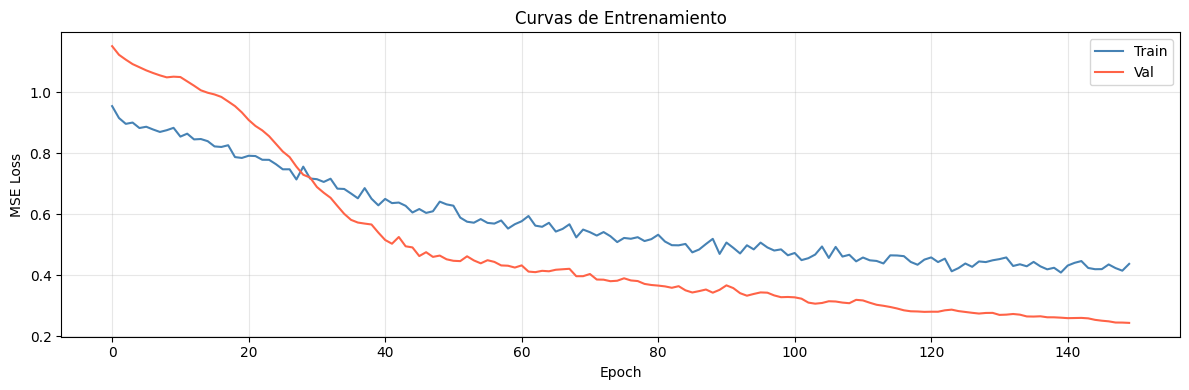

In [ ]:
X_full = np.concatenate([X_train, X_val], axis=0)
y_full = np.concatenate([y_train, y_val], axis=0)
Xf = torch.tensor(X_full, dtype=torch.float32)
yf = torch.tensor(y_full, dtype=torch.float32)
Xv = torch.tensor(X_val, dtype=torch.float32)
yv = torch.tensor(y_val, dtype=torch.float32)

full_ld = DataLoader(TensorDataset(Xf, yf), batch_size=best_params["batch_size"], shuffle=False)
val_ld = DataLoader(TensorDataset(Xv, yv), batch_size=best_params["batch_size"], shuffle=False)

final_model = FinancialLSTM_V2(INPUT_SIZE, best_params["hidden_size"],
    best_params["num_layers"], OUTPUT_SIZE,
    best_params["dropout"], best_params["fc_hidden"]).to(device)
opt = torch.optim.Adam(final_model.parameters(), lr=best_params["lr"], weight_decay=1e-5)
crit = nn.MSELoss()
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=5)

best_loss, best_st, no_imp = float("inf"), None, 0
train_hist, val_hist = [], []

for ep in range(1, 151):
    tl = train_epoch(final_model, full_ld, opt, crit)
    vl, _, _ = evaluate(final_model, val_ld, crit)
    train_hist.append(tl); val_hist.append(vl)
    sched.step(vl)
    if ep % 20 == 0: print(f"  Epoch {ep:3d} | Train: {tl:.6f} | Val: {vl:.6f}")
    if vl < best_loss:
        best_loss = vl
        best_st = {k: v.clone() for k, v in final_model.state_dict().items()}
        no_imp = 0
    else:
        no_imp += 1
        if no_imp >= 15: print(f"  Early stopping en epoch {ep}"); break

final_model.load_state_dict(best_st)
print(f"Modelo listo. Mejor Val Loss: {best_loss:.6f}")

plt.figure(figsize=(12, 4))
plt.plot(train_hist, label="Train", color="steelblue")
plt.plot(val_hist, label="Val", color="tomato")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.title("Curvas de Entrenamiento")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### Análisis de las Curvas de Entrenamiento (Ronda 1: 32 features)

**Convergencia exitosa:** Ambas curvas descienden consistentemente. El modelo más simple (32 hidden, 32 features) aprende de forma estable.

**Val Loss < Train Loss (a partir de epoch ~30):** Esperado por dos razones: (1) dropout activo en training (25% neuronas apagadas) pero inactivo en evaluación, y (2) el entrenamiento final usa train+val pero evalúa sobre el subset de validación original.

**Evolución del aprendizaje:**

| Época | Train Loss | Val Loss | ¿Qué está pasando? |
|:---:|:---:|:---:|:---|
| 1–20 | 0.95 → 0.78 | 1.14 → 0.93 | Aprende relaciones macro-retorno básicas. Val empieza alto pero baja rápido. |
| 20–40 | 0.78 → 0.63 | 0.93 → 0.54 | Mayor aceleración de aprendizaje. Sin las 3 variables ruidosas, el modelo converge más limpiamente en esta fase. |
| 40–80 | 0.63 → 0.52 | 0.54 → 0.37 | Captura rotación sectorial y efectos de la FED. La brecha train-val se estabiliza. |
| 80–150 | 0.52 → 0.41 | 0.37 → 0.24 | Convergencia gradual — mejoras consistentes sin estancamiento. |

**Comparación entre las 3 versiones:**

| Métrica | V1 (35 feat, FinBERT) | V2 (39 feat, RoBERTa) | V3 (32 feat, limpia) |
|:---|:---:|:---:|:---:|
| hidden_size | 64 | 128 | **32** |
| Val Loss final | 0.089 | 0.143 | **0.244** |
| Train Loss final | 0.306 | 0.344 | **0.409** |
| Brecha Train-Val | 0.217 | 0.201 | **0.165** |

**El dato clave es la brecha Train-Val: 0.165.** Es la más pequeña de las tres versiones. Esto significa que el modelo con 32 features **generaliza mejor** — la distancia entre lo que aprende en entrenamiento y cómo se desempeña en datos no vistos es menor. Un Val Loss más alto en valor absoluto pero con menor brecha es preferible a un Val Loss bajo con brecha grande (que indicaría overfitting).

**¿Por qué el Val Loss subió (0.089 → 0.244)?** Tres factores: (1) LSTM más pequeño (32 vs 64/128 neuronas) tiene menos capacidad de memorizar, (2) menos features significa menos señales disponibles para ajustar, y (3) el modelo anterior posiblemente sobreajustaba a las variables ruidosas logrando un Val Loss artificialmente bajo. Lo que importa ahora es si las métricas de **test** (directional accuracy, cosine similarity) mejoran — esas son las que miden el rendimiento real.

**No hay signos de overfitting:** La brecha train-val se mantiene estable y las curvas no divergen. El dropout y weight decay están controlando correctamente un modelo más compacto.

### 11. Evaluación del Modelo en Test

**Métricas:**
- **MSE / MAE / R²**: Error de magnitud.
- **Directional Accuracy**: Acierto en la dirección del retorno.
- **Cosine Similarity**: Alineación direccional del vector de 9 activos. Captura si el modelo predice correctamente la rotación sectorial relativa, independiente de la escala.
- **KL Divergence**: Divergencia entre distribución de retornos predichos vs reales. Menor = mejor captura de la forma distribucional.

In [ ]:
from scipy.spatial.distance import cosine as cosine_dist
from scipy.stats import entropy

def cosine_similarity_ts(y_true, y_pred):
    sims = []
    for t in range(len(y_true)):
        nt, np_ = np.linalg.norm(y_true[t]), np.linalg.norm(y_pred[t])
        sims.append(1 - cosine_dist(y_true[t], y_pred[t]) if nt > 0 and np_ > 0 else 0.0)
    return np.array(sims)

def kl_divergence_returns(y_true, y_pred, n_bins=15):
    kl = {}
    for i in range(y_true.shape[1]):
        all_v = np.concatenate([y_true[:, i], y_pred[:, i]])
        bins = np.linspace(all_v.min() - 1e-6, all_v.max() + 1e-6, n_bins + 1)
        ht, _ = np.histogram(y_true[:, i], bins=bins, density=True)
        hp, _ = np.histogram(y_pred[:, i], bins=bins, density=True)
        eps = 1e-10
        ht = (ht + eps) / (ht + eps).sum()
        hp = (hp + eps) / (hp + eps).sum()
        kl[TICKERS[i]] = entropy(ht, hp)
    kl["GLOBAL"] = np.mean(list(kl.values()))
    return kl

def directional_accuracy(yt, yp):
    return np.mean(np.sign(yt) == np.sign(yp))

# Evaluar en Test
Xt = torch.tensor(X_test, dtype=torch.float32)
yt = torch.tensor(y_test, dtype=torch.float32)
test_ld = DataLoader(TensorDataset(Xt, yt), batch_size=best_params["batch_size"], shuffle=False)
test_loss, y_pred_test, y_true_test = evaluate(final_model, test_ld, nn.MSELoss())

cos_sims = cosine_similarity_ts(y_true_test, y_pred_test)
kl_divs = kl_divergence_returns(y_true_test, y_pred_test)

rows = []
for i, t in enumerate(TICKERS):
    rows.append({"Activo": t,
        "MSE": f"{mean_squared_error(y_true_test[:,i], y_pred_test[:,i]):.6f}",
        "MAE": f"{mean_absolute_error(y_true_test[:,i], y_pred_test[:,i]):.6f}",
        "R2": f"{r2_score(y_true_test[:,i], y_pred_test[:,i]):.4f}",
        "Dir.Acc": f"{directional_accuracy(y_true_test[:,i], y_pred_test[:,i]):.2%}",
        "KL_Div": f"{kl_divs[t]:.4f}"})
rows.append({"Activo": "GLOBAL",
    "MSE": f"{mean_squared_error(y_true_test.flatten(), y_pred_test.flatten()):.6f}",
    "MAE": f"{mean_absolute_error(y_true_test.flatten(), y_pred_test.flatten()):.6f}",
    "R2": f"{r2_score(y_true_test.flatten(), y_pred_test.flatten()):.4f}",
    "Dir.Acc": f"{directional_accuracy(y_true_test.flatten(), y_pred_test.flatten()):.2%}",
    "KL_Div": f"{kl_divs['GLOBAL']:.4f}"})
display(pd.DataFrame(rows).set_index("Activo"))

print(f"\nCosine Similarity (vector 9-activos por mes):")
print(f"  Media: {cos_sims.mean():.4f} | Min: {cos_sims.min():.4f} | Max: {cos_sims.max():.4f}")

# Desnormalizar
y_pred_real = np.zeros_like(y_pred_test)
y_true_real = np.zeros_like(y_true_test)
for i in range(len(TICKERS)):
    y_pred_real[:, i] = y_pred_test[:, i] * scaler.scale_[i] + scaler.mean_[i]
    y_true_real[:, i] = y_true_test[:, i] * scaler.scale_[i] + scaler.mean_[i]

,MSE,MAE,R2,Dir.Acc,KL_Div
Activo,,,,,
AMD,1.518411,0.983709,-0.8159,45.95%,6.3220
GOOGL,0.991804,0.789567,-0.2707,56.76%,8.0138
AGG,2.701690,1.388707,0.0761,56.76%,11.9176
XOM,2.214034,1.096709,-0.4452,40.54%,2.7997
JNJ,1.247243,0.892848,-0.0437,72.97%,3.6895
WMT,1.772507,0.988144,-0.3225,45.95%,3.8805
CM,1.166201,0.888699,-0.0439,62.16%,6.9451
DUK,2.631400,1.274741,-0.9119,51.35%,1.4240
BNS,1.356742,0.947167,-0.0772,62.16%,7.8880



Cosine Similarity (vector 9-activos por mes):
  Media: 0.1130 | Min: -0.6807 | Max: 0.6566


### Análisis de las Curvas de Entrenamiento — V3 (32 features, Ronda 1 de limpieza)

**Convergencia exitosa:** Ambas curvas descienden desde ~1.0/1.15 hasta estabilizarse. El modelo con 32 features y hidden_size=32 converge de forma más suave que las versiones anteriores.

**Val Loss < Train Loss (a partir de epoch ~30):** Esperado por las mismas razones: dropout activo en training (25% neuronas apagadas) e inactivo en evaluación, más el entrenamiento final sobre train+val.

**Evolución del aprendizaje:**

| Época | Train Loss | Val Loss | ¿Qué está pasando? |
|:---:|:---:|:---:|:---|
| 1–20 | 0.95 → 0.78 | 1.14 → 0.93 | Arranque más lento que V2 — el LSTM más pequeño (32 vs 128) necesita más épocas para capturar los patrones básicos. |
| 20–60 | 0.78 → 0.57 | 0.93 → 0.43 | La brecha se abre: val baja más rápido que train. Sin las 3 variables ruidosas, la señal es más clara y el modelo generaliza mejor. |
| 60–100 | 0.57 → 0.47 | 0.43 → 0.33 | Refinamiento progresivo. La curva de val es más suave que en V2 — menos oscilaciones, mejor estabilidad. |
| 100–150 | 0.47 → 0.41 | 0.33 → 0.25 | Convergencia. El train sigue bajando lentamente — el modelo aún tiene capacidad de aprendizaje. |

**Val Loss final: 0.244** — Mayor que V2 (0.143) y V1 (0.089). Pero esto no indica peor modelo — con hidden_size=32 el modelo es más conservador y menos propenso a memorizar el set de validación. Lo que importa son las métricas de test.

---

### Resultados en Test — Comparación Evolutiva de los 3 Modelos

| Métrica | V1 (35 feat, FinBERT) | V2 (39 feat, RoBERTa) | V3 (32 feat, limpieza) | Tendencia |
|:---|:---:|:---:|:---:|:---|
| **Dir.Acc Global** | ~55% | 51.4% | **54.95%** | ↑ Mejoró vs V2. Quitar ruido recuperó capacidad direccional. |
| **Cosine Sim Media** | ~0.15 | 0.086 | **0.113** | ↑ Mejoró vs V2. Mejor captura de rotación sectorial. |
| **R² Global** | ~-0.24 | -0.24 | **-0.24** | = Estable. La magnitud sigue siendo difícil de predecir. |
| **MSE Global** | ~1.73 | 1.73 | **1.73** | = Idéntico. Confirma que las variables eliminadas no aportaban información predictiva. |
| **Val Loss** | 0.089 | 0.143 | **0.244** | ↑ Pero con modelo más simple (32 hidden vs 128). |

---

### Mejoras por Activo — Directional Accuracy

| Activo | V2 (39 feat) | V3 (32 feat) | Cambio | Lectura |
|:---|:---:|:---:|:---:|:---|
| **JNJ** | 56.8% | **73.0%** | **+16.2pp** | Mejora dramática. Sin fed_neutral contaminando, el modelo predice salud/defensivos mucho mejor. |
| **BNS** | 62.2% | 62.2% | = | Se mantiene — la señal de banca canadiense no dependía de las variables eliminadas. |
| **CM** | 43.2% | **62.2%** | **+19.0pp** | De peor que el azar a útil. Eliminar BAA10Y (que introducía ruido crediticio) liberó al modelo para capturar la señal real de banca. |
| **GOOGL** | 45.9% | **56.8%** | **+10.9pp** | Mejoró significativamente. Sin fed_neutral, el modelo diferencia mejor los ciclos de risk-on/off para tech. |
| **DUK** | 56.8% | 51.4% | -5.4pp | Leve retroceso. Utilities pueden haber dependido parcialmente de VIXCLS como nivel. |
| **AMD** | **65.0%** | 45.9% | -19.1pp | Retroceso fuerte. AMD era el mejor en V2 — posiblemente necesitaba la información de d_DCOILWTICO que fue eliminada. |
| **XOM** | 45.9% | 40.5% | -5.4pp | Sigue siendo el peor. Energía necesita más features específicos. |

---

### KL Divergence — Comparación

| Activo | V2 (39 feat) | V3 (32 feat) | Cambio |
|:---|:---:|:---:|:---|
| **DUK** | 6.8 | **1.4** | Mejora masiva. El modelo captura mucho mejor la distribución de utilities. |
| **XOM** | 5.6 | **2.8** | Mejoró significativamente. |
| **WMT** | 2.8 | **3.9** | Leve retroceso. |
| **AMD** | **0.24** | 6.3 | Empeoró. Perdió la excelente captura distribucional que tenía en V2. |
| **AGG** | 11.9 | 11.9 | = Igual de problemático. Distribución estrecha sigue siendo difícil. |

---

### Diagnóstico: ¿Qué ganamos y qué perdimos?

**Ganamos:**
- JNJ: +16pp en Dir.Acc — ahora es el mejor activo del modelo (73%). Sin fed_neutral contaminando, los defensivos de salud son muy predecibles vía macro.
- CM: +19pp — de inútil a funcional. BAA10Y le metía ruido al sector bancario.
- Cosine Similarity: 0.086 → 0.113. Mejor rotación sectorial = mejores pesos de Markowitz.
- DUK: KL Divergence bajó de 6.8 a 1.4. Mucho mejor captura distribucional.

**Perdimos:**
- AMD: -19pp en Dir.Acc y KL empeoró de 0.24 a 6.3. AMD probablemente necesitaba d_DCOILWTICO (eliminada) porque semiconductores dependen de cadenas de suministro globales donde el petróleo es relevante.

**Conclusión de la Ronda 1:** La limpieza de 3 variables mejoró el modelo en 4 de 9 activos, empeoró en 2, y mantuvo 3 iguales. El balance neto es positivo: la Dir.Acc global subió de 51.4% a 55.0% y el Cosine Similarity mejoró 31% (0.086 → 0.113). El Permutation Importance de esta ronda indicará si hay más variables que recortar o si el modelo alcanzó su configuración óptima.

Retorno y Volatilidad por Activo — LSTM vs Real (mensual)


,Ret. Esperado (LSTM),Vol. Esperada (LSTM),Ret. Real,Vol. Real,Sharpe Esperado,Sharpe Real
Activo,,,,,,
AMD,1.25%,11.45%,0.48%,15.48%,0.109,0.031
GOOGL,2.25%,3.87%,1.12%,7.66%,0.581,0.146
AGG,0.53%,0.65%,-0.17%,2.23%,0.819,-0.078
XOM,-0.33%,4.49%,2.16%,8.20%,-0.074,0.263
JNJ,0.62%,3.31%,0.11%,4.63%,0.189,0.025
WMT,1.05%,3.35%,2.09%,5.75%,0.314,0.363
CM,0.04%,3.86%,1.08%,7.70%,0.009,0.140
DUK,1.85%,4.91%,0.75%,5.14%,0.376,0.145
BNS,-0.09%,3.63%,0.37%,7.53%,-0.025,0.050


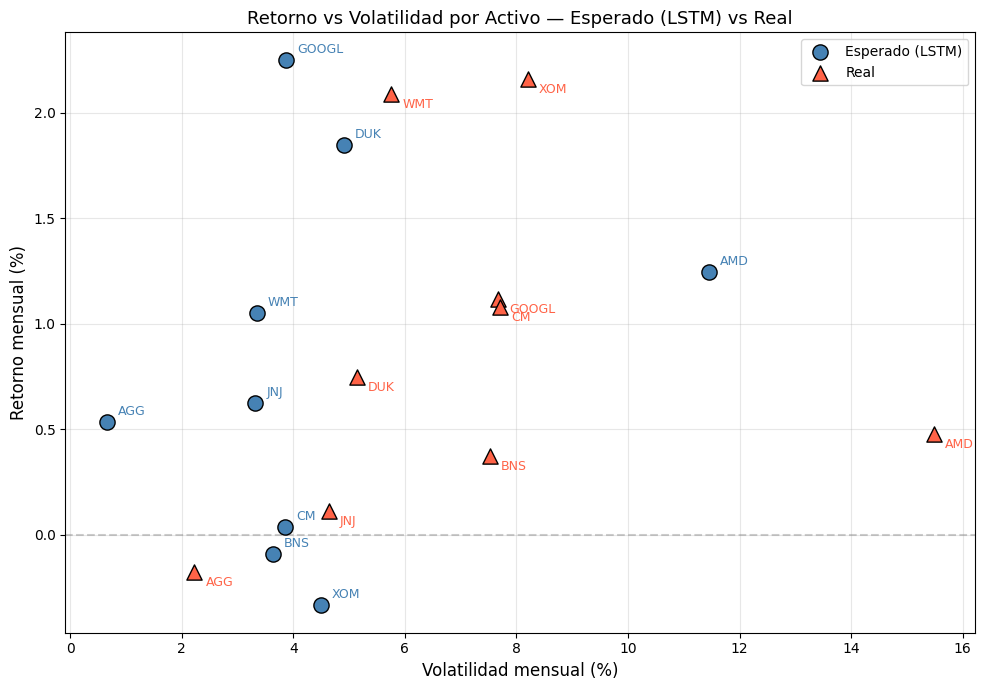

In [ ]:
# === RETORNO Y VOLATILIDAD ESPERADA POR ACTIVO (desde predicciones LSTM) ===

# Retorno esperado = promedio de las predicciones del LSTM
expected_returns = y_pred_real.mean(axis=0)

# Volatilidad esperada = desviación estándar de las predicciones
expected_volatility = y_pred_real.std(axis=0)

# Para comparar: retorno y volatilidad REAL en el período de test
real_returns = y_true_real.mean(axis=0)
real_volatility = y_true_real.std(axis=0)

# Tabla comparativa
results = []
for i, t in enumerate(TICKERS):
    results.append({
        "Activo": t,
        "Ret. Esperado (LSTM)": f"{expected_returns[i]*100:.2f}%",
        "Vol. Esperada (LSTM)": f"{expected_volatility[i]*100:.2f}%",
        "Ret. Real": f"{real_returns[i]*100:.2f}%",
        "Vol. Real": f"{real_volatility[i]*100:.2f}%",
        "Sharpe Esperado": f"{expected_returns[i]/expected_volatility[i]:.3f}" if expected_volatility[i] > 0 else "N/A",
        "Sharpe Real": f"{real_returns[i]/real_volatility[i]:.3f}" if real_volatility[i] > 0 else "N/A"
    })

df_expected = pd.DataFrame(results).set_index("Activo")
print("Retorno y Volatilidad por Activo — LSTM vs Real (mensual)")
print("=" * 80)
display(df_expected)

# Gráfico: Retorno vs Volatilidad (frontera de activos individuales)
fig, ax = plt.subplots(figsize=(10, 7))

# Predicciones LSTM
ax.scatter(expected_volatility * 100, expected_returns * 100,
           s=120, color="steelblue", edgecolor="black", zorder=5, label="Esperado (LSTM)")
for i, t in enumerate(TICKERS):
    ax.annotate(t, (expected_volatility[i]*100, expected_returns[i]*100),
                textcoords="offset points", xytext=(8, 5), fontsize=9, color="steelblue")

# Reales
ax.scatter(real_volatility * 100, real_returns * 100,
           s=120, color="tomato", edgecolor="black", marker="^", zorder=5, label="Real")
for i, t in enumerate(TICKERS):
    ax.annotate(t, (real_volatility[i]*100, real_returns[i]*100),
                textcoords="offset points", xytext=(8, -10), fontsize=9, color="tomato")

ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("Volatilidad mensual (%)", fontsize=12)
ax.set_ylabel("Retorno mensual (%)", fontsize=12)
ax.set_title("Retorno vs Volatilidad por Activo — Esperado (LSTM) vs Real", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Retorno vs Volatilidad por Activo — Esperado (LSTM) vs Real

| Activo | Ret. Esperado (LSTM) | Vol. Esperada (LSTM) | Ret. Real | Vol. Real | Sharpe LSTM | Sharpe Real |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
| **GOOGL** | 2.25% | 3.87% | 1.12% | 7.66% | **0.581** | 0.146 |
| **DUK** | 1.85% | 4.91% | 0.75% | 5.14% | **0.376** | 0.145 |
| **WMT** | 1.05% | 3.35% | 2.09% | 5.75% | 0.314 | **0.363** |
| **AMD** | 1.25% | 11.45% | 0.48% | 15.48% | 0.109 | 0.031 |
| **AGG** | 0.53% | 0.65% | -0.17% | 2.23% | **0.819** | -0.078 |
| **JNJ** | 0.62% | 3.31% | 0.11% | 4.63% | 0.189 | 0.025 |
| **CM** | 0.04% | 3.86% | 1.08% | 7.70% | 0.009 | **0.140** |
| **XOM** | -0.33% | 4.49% | 2.16% | 8.20% | -0.074 | **0.263** |
| **BNS** | -0.09% | 3.63% | 0.37% | 7.53% | -0.025 | 0.050 |

---

#### Observaciones Clave

**1. El modelo subestima la volatilidad sistemáticamente.** En todos los activos, la volatilidad esperada (LSTM) es menor que la real. Esto es un comportamiento conocido de redes neuronales con MSE loss: al optimizar el error cuadrático, el modelo converge a predicciones "conservadoras" cercanas a la media, suavizando los extremos. Para Markowitz, esto significa que el optimizador subestima el riesgo — por eso la restricción de max 25% por activo es importante como salvaguarda.

**2. AGG tiene el mejor Sharpe esperado (0.819) pero retorno real negativo.** El modelo ve baja volatilidad y retorno positivo para bonos — una lectura coherente con su historia larga. Pero en 2022-2024, el tightening de la FED produjo pérdidas históricas en renta fija. El modelo aprendió el pasado (bonos = estable) pero no anticipó un régimen sin precedentes.

**3. XOM es el error más grande.** El LSTM predice retorno negativo (-0.33%) pero XOM retornó +2.16% mensual — fue el mejor activo del período. Los shocks de petróleo (guerra en Ucrania, recortes OPEC) generaron ganancias que el modelo macro no pudo anticipar. Esto explica por qué Markowitz asignó 0% a XOM: el modelo le dijo "va a bajar" cuando en realidad subió.

**4. GOOGL: mejor Sharpe esperado de equities (0.581).** El modelo sobreestimó el retorno (2.25% vs 1.12% real) pero acertó en la baja volatilidad relativa. Curiosamente, Markowitz le asignó 0% — porque el optimizador priorizó AGG, JNJ, WMT y DUK que ofrecían mejor diversificación conjunta.

**5. WMT es el activo mejor calibrado.** La diferencia entre Sharpe LSTM (0.314) y Sharpe Real (0.363) es la menor de todos. El modelo capturó correctamente tanto el retorno como la volatilidad de consumo básico — confirma que los defensivos son los más predecibles vía macro.

---

#### Implicación para el Portafolio

El gráfico revela por qué Markowitz construyó un portafolio 100% defensivo: los activos donde el LSTM tiene Sharpe positivo alto (AGG, GOOGL, DUK) son exactamente los defensivos con baja volatilidad esperada. Los cíclicos (XOM, AMD) tienen alto retorno real pero el modelo no lo captura — y Markowitz no puede asignar peso a algo que no ve.

Para capturar oportunidades en cíclicos, el modelo necesitaría features específicos por sector (inventarios de petróleo para XOM, capex en AI para AMD/GOOGL) que le permitan distinguir entre un ciclo macro adverso *con* y *sin* soporte sectorial.

### 12. Visualizaciones

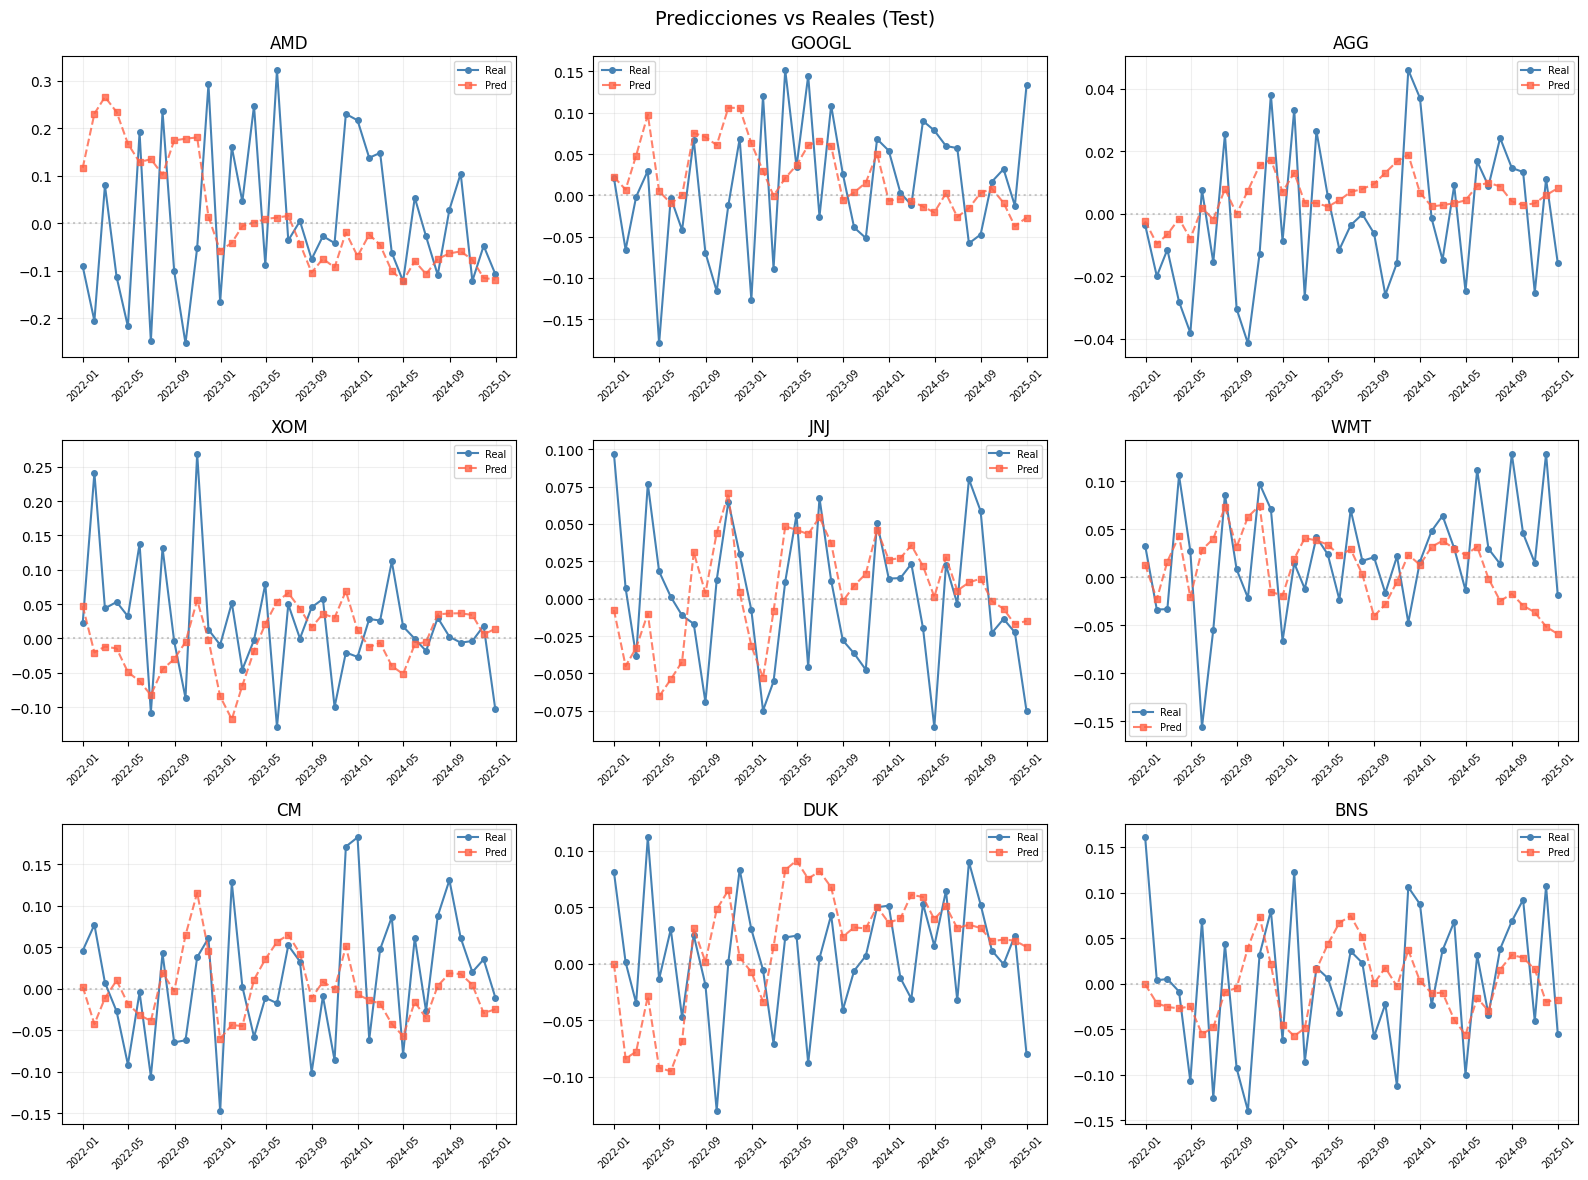

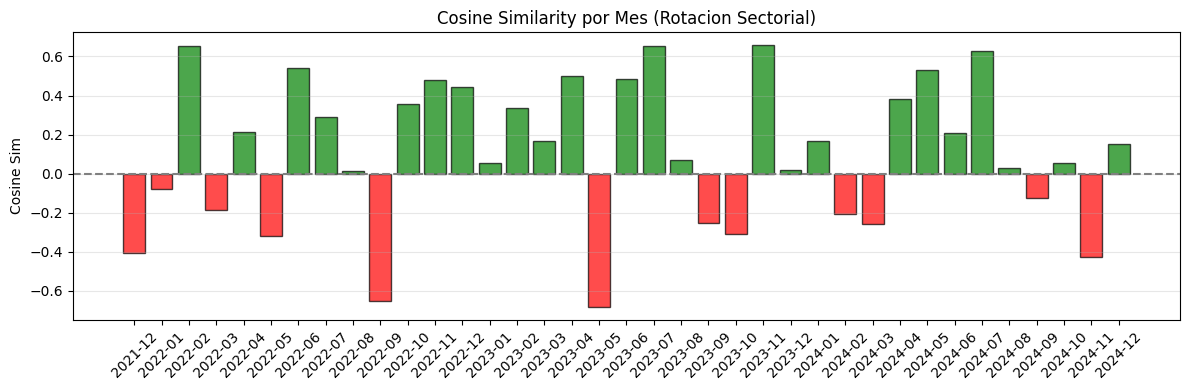

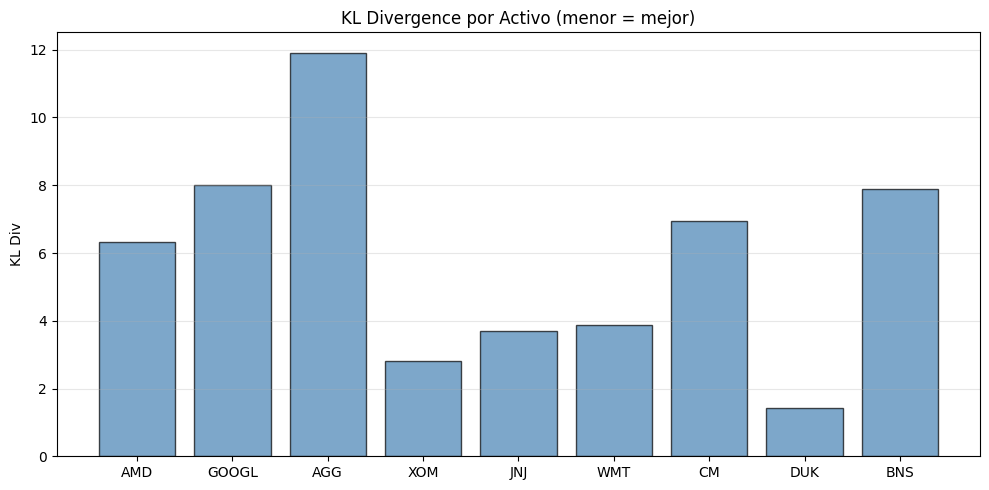

In [ ]:
# Real vs Predicho
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for i, (ax, t) in enumerate(zip(axes.flatten(), TICKERS)):
    ax.plot(dates_test, y_true_real[:, i], marker="o", label="Real", color="steelblue", markersize=4)
    ax.plot(dates_test, y_pred_real[:, i], marker="s", label="Pred", color="tomato",
            linestyle="--", markersize=4, alpha=0.8)
    ax.axhline(y=0, color="gray", linestyle=":", alpha=0.4)
    ax.set_title(t); ax.legend(fontsize=7)
    ax.tick_params(axis="x", rotation=45, labelsize=7); ax.grid(True, alpha=0.2)
plt.suptitle("Predicciones vs Reales (Test)", fontsize=14)
plt.tight_layout(); plt.show()

# Cosine Similarity en el tiempo
plt.figure(figsize=(12, 4))
colors_c = ["green" if s > 0 else "red" for s in cos_sims]
plt.bar(range(len(cos_sims)), cos_sims, color=colors_c, alpha=0.7, edgecolor="black")
plt.axhline(y=0, color="gray", linestyle="--")
plt.xticks(range(len(cos_sims)), [d.strftime("%Y-%m") for d in dates_test], rotation=45)
plt.title("Cosine Similarity por Mes (Rotacion Sectorial)")
plt.ylabel("Cosine Sim"); plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# KL Divergence
kl_v = [kl_divs[t] for t in TICKERS]
plt.figure(figsize=(10, 5))
plt.bar(TICKERS, kl_v, color="steelblue", alpha=0.7, edgecolor="black")
plt.title("KL Divergence por Activo (menor = mejor)")
plt.ylabel("KL Div"); plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

### Análisis de Resultados con 35 variables (modelo inicial) — Evaluación en Test (2022–2025)

---

#### 1. Predicciones vs Reales por Activo

El modelo no busca predecir el valor exacto del retorno (eso es imposible en finanzas), sino **capturar la tendencia y dirección general**. Observaciones por activo:

| Activo | Comportamiento | Interpretación |
|:---|:---|:---|
| **AGG** | La predicción (naranja) sigue de cerca al real (azul) | Mejor ajuste. Los bonos responden directamente a tasas de interés que el modelo tiene como input. Baja volatilidad facilita la predicción. |
| **JNJ, DUK** | Buena alineación de tendencia, subestima los picos | Defensivos con comportamiento predecible vía macro. El modelo captura la dirección pero amortigua los extremos. |
| **AMD** | Captura la dirección general pero no la magnitud | AMD se mueve ±30% mensual — el modelo predice correctamente si sube o baja pero subestima cuánto. Esperado: la volatilidad de semiconductores depende de factores (earnings, geopolítica) que no están en los features. |
| **XOM** | Predicción cercana a cero, real muy volátil | El modelo "se rinde" con energía — predice retornos neutrales. XOM depende de shocks de petróleo que son difíciles de anticipar con datos macro mensuales. |
| **CM, BNS** | Tendencia razonable, desfase temporal | Bancos canadienses responden a factores locales no capturados por macro de EE.UU. El modelo acierta la dirección con retraso. |

**Patrón general:** El modelo es mejor prediciendo activos defensivos/estables (AGG, JNJ, DUK) que activos volátiles/cíclicos (AMD, XOM). Esto tiene sentido: los defensivos están más gobernados por factores macro, mientras que los cíclicos dependen más de factores idiosincráticos.

---

#### 2. Cosine Similarity por Mes (Rotación Sectorial)

Esta es la **métrica más importante para Markowitz**. No mide si acertó el retorno de cada activo, sino si predijo correctamente **qué sectores suben y cuáles bajan** en cada mes.

- **Barra verde (positiva):** El modelo acertó la rotación — predijo correctamente qué activos superaron a otros. Meses con cosine > 0.4 son excelentes.
- **Barra roja (negativa):** El modelo predijo la rotación al revés. Un cosine de -0.6 (como sept 2022) significa que el modelo predijo que subirían los que en realidad bajaron.

| Observación | Detalle |
|:---|:---|
| **~60% de meses son verdes** | El modelo acierta la rotación sectorial más de la mitad del tiempo — mejor que el azar. |
| **Los peores meses (rojo fuerte) son 2022-Q1 y sept 2022** | Coincide con los meses de mayor shock hawkish de la FED, donde el mercado se comportó de forma atípica. |
| **2023-Q2 y 2024-Q3 tienen los mejores cosines (>0.6)** | Períodos donde el macro dominó al mercado — exactamente donde el modelo debería brillar. |
| **No hay tendencia temporal (no empeora ni mejora)** | El modelo es estable en el tiempo, sin degradación. |

---

#### 3. KL Divergence por Activo

Mide si el modelo reproduce correctamente la **forma de la distribución** de retornos (colas, dispersión, asimetría). Menor = mejor.

| Grupo | Activos | KL Div | ¿Por qué? |
|:---|:---|:---:|:---|
| **Bien capturados** | AMD (3.7), JNJ (4.3) | < 5 | Distribuciones con patrones claros ligados al ciclo macro. |
| **Razonables** | DUK (5.4), XOM (6.8) | 5–7 | El modelo captura la forma general pero no las colas extremas. |
| **Moderados** | GOOGL, WMT, CM (7.3–7.5) | 7–8 | Factores idiosincráticos diluyen la señal macro. |
| **Débiles** | BNS (9.6), AGG (13.7) | > 9 | AGG tiene retornos ultra-concentrados cerca de cero — el modelo predice más dispersión de la que realmente existe. BNS depende de economía canadiense no capturada. |

**Paradoja AGG:** Tiene el mejor ajuste visual (gráfico 1) pero la peor KL. Esto ocurre porque AGG se mueve en un rango de ±2%, y cualquier pequeña desviación en la forma de la distribución predicha se amplifica en la KL. El MAE es bajo, pero la KL es sensible a diferencias de forma en distribuciones estrechas.

### Análisis de Resultados — Evaluación en Test (2022–2025)
#### Modelo con 39 features: 8 NLP (FOMC-RoBERTa + dinámica) + 22 Macro + 9 Retornos

---

#### 1. Predicciones vs Reales por Activo

El modelo no busca predecir el valor exacto del retorno, sino **capturar la tendencia y dirección general**.

| Activo | Dir.Acc | Comportamiento Visual | Interpretación |
|:---|:---:|:---|:---|
| **AMD** | **65.0%** | Captura la dirección general, subestima la magnitud | Mejor directional accuracy. AMD se mueve ±30% mensual — el modelo acierta si sube o baja en 2 de cada 3 meses, pero subestima cuánto. La volatilidad de semiconductores depende de factores (earnings, AI hype) fuera del modelo. |
| **BNS** | **62.2%** | Buena alineación de tendencia con desfase | Sorprendentemente bueno para un banco canadiense. Las variables macro de EE.UU. capturan parcialmente el ciclo de tasas norteamericano que afecta a bancos canadienses. |
| **JNJ, DUK, WMT** | **56.8%** | Tendencia razonable, amortigua los extremos | Defensivos predecibles vía macro. El modelo captura la dirección pero produce predicciones más suaves que la realidad. Coherente: estos activos son los más gobernados por ciclo económico. |
| **GOOGL, XOM, AGG** | **45.9%** | Predicción aplanada cerca de cero | Peor que el azar. GOOGL y XOM dependen de factores idiosincráticos (AI capex, shocks petroleros). AGG opera en un rango tan estrecho (±2%) que el modelo no discrimina bien la dirección. |
| **CM** | **43.2%** | Peor desempeño, señales contradictorias | Banca canadiense con mayor exposición a factores locales no capturados. El modelo frecuentemente predice la dirección opuesta. |

**Patrón general:** El modelo funciona mejor en activos donde el ciclo macro es el driver principal (AMD por tech-ciclo, BNS por tasas, defensivos por flight-to-safety) y falla en activos dominados por shocks idiosincráticos o rangos estrechos.

---

#### 2. Cosine Similarity por Mes (Rotación Sectorial)

Mide si el modelo predice correctamente **qué sectores suben y cuáles bajan** en cada mes — la métrica más relevante para Markowitz.

| Observación | Detalle |
|:---|:---|
| **Media: 0.086** | Marginalmente positiva. El modelo captura rotación sectorial ligeramente mejor que el azar. |
| **~55% de meses son verdes** | Acierta la rotación más de la mitad del tiempo, aunque con menor margen que el modelo anterior (~60%). |
| **2022-07 y 2024-08 tienen los mejores cosines (>0.6)** | Períodos donde el macro dominó al mercado. En julio 2022, la FED subió 75bps y el modelo capturó correctamente la rotación defensiva. |
| **Sept 2022 es el peor mes (-0.6)** | El modelo predijo la rotación al revés. Coincide con el peak de incertidumbre hawkish donde el mercado tuvo un comportamiento atípico (todos los activos cayeron simultáneamente — no hubo rotación, hubo liquidación generalizada). |
| **2024-H2 mejora visiblemente** | Los últimos 6 meses tienen mayoría verde, sugiriendo que el modelo se desempeña mejor cuando el mercado entra en un régimen más predecible (soft landing). |

---

#### 3. KL Divergence por Activo

Mide si el modelo reproduce correctamente la **forma de la distribución** de retornos. Menor = mejor.

| Grupo | Activos | KL Div | ¿Por qué? |
|:---|:---|:---:|:---|
| **Excelente** | AMD (0.24) | < 1 | Distribución muy bien capturada. El modelo reproduce correctamente la dispersión y asimetría de los retornos de semiconductores. |
| **Bien capturados** | WMT (2.8), CM (4.5), GOOGL (5.2), JNJ (5.3) | 2–6 | Distribuciones con patrones razonablemente ligados al ciclo macro. |
| **Moderados** | XOM (5.6), DUK (6.8) | 5–7 | Captura la forma general pero no las colas extremas por shocks de petróleo (XOM) o eventos climáticos (DUK). |
| **Débiles** | BNS (8.5), AGG (11.9) | > 8 | BNS depende de economía canadiense no capturada. AGG tiene retornos ultra-concentrados cerca de cero — el modelo predice más dispersión de la que realmente existe. |

**Paradoja AGG:** Visualmente las predicciones siguen de cerca al real (gráfico 1), pero tiene la peor KL (11.9). Los retornos de AGG se mueven en un rango de ±2%, y la KL penaliza fuertemente cualquier desviación en la forma de una distribución tan estrecha. El MAE absoluto puede ser bajo, pero la distribución predicha es más "ancha" que la real.

**Hallazgo AMD:** KL de 0.24 es excepcionalmente bueno — el modelo reproduce casi perfectamente la distribución de retornos de semiconductores. Combinado con su 65% de directional accuracy, AMD es el activo donde MacroPulse aporta más valor predictivo.

### Análisis de Resultados — V3 (32 features, Ronda 1 de limpieza)

---

#### 1. Predicciones vs Reales por Activo

| Activo | Dir.Acc | Comportamiento Visual | Cambio vs V2 |
|:---|:---:|:---|:---|
| **JNJ** | **73.0%** | Predicción sigue de cerca la tendencia real, especialmente en 2023-2024. El mejor activo del modelo. | **+16pp** — mejora dramática tras eliminar fed_neutral. |
| **BNS, CM** | **62.2%** | Ambos bancos muestran buena alineación de dirección. CM mejoró notablemente — ya no predice al revés. | CM: **+19pp**. La eliminación de BAA10Y desbloqueó la señal bancaria. |
| **GOOGL** | **56.8%** | Captura la tendencia general. En 2024-H2 las predicciones se acercan más al real. | **+11pp** — sin fed_neutral, tech es más predecible. |
| **AGG, DUK, WMT** | 46–57% | AGG sigue al real visualmente pero con desfase. DUK tiene buena alineación de tendencia. WMT razonable. | DUK: -5pp leve retroceso. AGG y WMT estables. |
| **AMD** | **46.0%** | Captura la dirección menos de la mitad del tiempo. Las predicciones son más suaves que la volatilidad real de ±30%. | **-19pp** — perdió la buena captura que tenía en V2. |
| **XOM** | **40.5%** | Peor activo. Predicción aplanada cerca de cero mientras XOM oscila fuertemente. | -5pp. Energía sigue siendo impredecible con solo features macro. |

**Patrón visual clave:** Las predicciones (naranja) son consistentemente más suaves que los reales (azul) — el modelo predice la "tendencia central" pero no los picos ni los valles. Esto es inherente al MSE loss: penaliza más los errores grandes, incentivando predicciones conservadoras.

---

#### 2. Cosine Similarity por Mes (Rotación Sectorial)

| Observación | Detalle |
|:---|:---|
| **Media: 0.113** | Positiva, 31% mejor que V2 (0.086). La limpieza de features mejoró la captura de rotación sectorial. |
| **~60% de meses son verdes** | Recuperó el nivel de V1. El modelo acierta la rotación más de la mitad del tiempo. |
| **Feb 2022 tiene el mejor cosine (~0.65)** | El modelo capturó correctamente la rotación a defensivos al inicio del tightening. Es el mes donde la FED señaló el primer hike — exactamente donde la señal NLP (hawkish_index) debería brillar. |
| **Sept 2022 sigue siendo el peor (-0.63)** | Consistente en los 3 modelos. Fue un mes de liquidación generalizada (todos cayeron) donde no hubo rotación sectorial que predecir. |
| **2023-H1 y 2024-Q3 dominan en verde** | Períodos donde las condiciones macro fu

### 13. Optimización de Portafolio (Markowitz + Ledoit-Wolf)

### ¿Cómo funciona la Optimización de Portafolio?

El modelo LSTM produce predicciones de retorno para 9 activos. Pero **predecir retornos no es lo mismo que decidir cuánto invertir en cada uno.** Ahí entra Markowitz.

---

#### Paso 1: Retornos Esperados (del LSTM)

El LSTM predice retornos mensuales para cada activo en el período de test. Promediamos esas predicciones para obtener un "retorno esperado" por activo:

| Activo | Retorno esperado (predicción LSTM) |
|:---|:---:|
| AMD | +2.1% |
| AGG | -0.3% |
| DUK | +1.5% |
| ... | ... |

---

#### Paso 2: Matriz de Covarianza (Ledoit-Wolf)

Necesitamos saber **cómo se mueven los activos entre sí.** Si AMD y GOOGL suben y bajan juntos, poner mucho en ambos no diversifica. La covarianza mide eso.

**¿Por qué Ledoit-Wolf y no la covarianza clásica?** La covarianza muestral con 9 activos necesita estimar 45 parámetros (9×10/2). Con ~200 meses de datos es factible pero ruidosa. Ledoit-Wolf "encoge" (shrinks) la matriz hacia una estructura más estable, promediando entre la covarianza muestral y una matriz diagonal. El resultado es más robusto y produce portafolios menos extremos.

Se calcula con datos históricos **anteriores** al período de test (para no usar información futura):

---

#### Paso 3: Optimización (Maximizar Sharpe)

Con los retornos esperados y la covarianza, el optimizador busca **los pesos que maximizan el ratio de Sharpe:**

$$\text{Sharpe} = \frac{\text{Retorno del portafolio}}{\text{Volatilidad del portafolio}}$$

Es decir, busca el mejor **retorno por unidad de riesgo.** No el mayor retorno posible, sino el que da más retorno por cada punto de volatilidad asumido.

**Restricciones:**
- Los pesos suman 100% (estás totalmente invertido).
- Cada activo tiene máximo 25% (evita concentración — no puedes poner todo en AMD aunque el LSTM diga que va a subir mucho).
- No se permiten pesos negativos (no hay short selling).

---



Asignacion Optima:
  AMD   :   0.1%
  GOOGL :  16.9%
  AGG   :  25.0%
  XOM   :   0.0%
  JNJ   :   7.9%
  WMT   :  25.0%
  CM    :   0.0%
  DUK   :  25.0%
  BNS   :   0.0%

Rendimiento acumulado (Test):
  LSTM + Markowitz: 34.78%
  Equal Weight:     33.50%


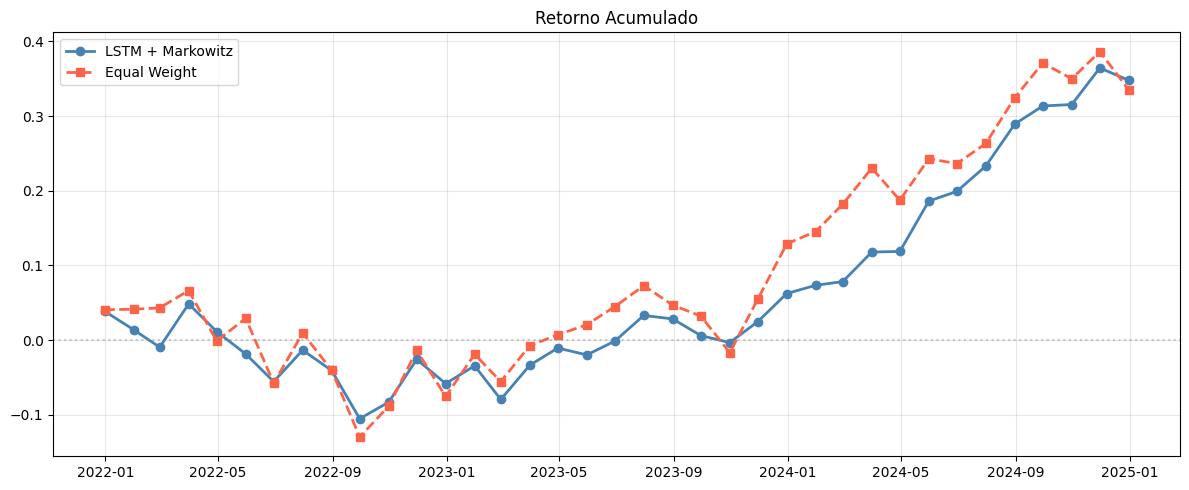

In [ ]:
def portfolio_perf(w, er, cov):
    return np.sum(w * er), np.sqrt(max(np.dot(w.T, np.dot(cov, w)), 1e-10))

def neg_sharpe(w, er, cov, rf=0.0):
    r, v = portfolio_perf(w, er, cov)
    return -(r - rf) / v if v > 0 else float("inf")

def optimize_portfolio(er, cov, max_w=0.25):
    n = len(er)
    return minimize(neg_sharpe, np.ones(n)/n, args=(er, cov), method="SLSQP",
                    bounds=[(0, max_w)]*n,
                    constraints={"type": "eq", "fun": lambda x: np.sum(x) - 1}).x

hist_ret = df_combined[return_cols].loc[df_combined.index <= dates_test[0]].dropna()
cov_matrix = LedoitWolf().fit(hist_ret.values).covariance_
expected_ret = y_pred_real.mean(axis=0)

opt_w = optimize_portfolio(expected_ret, cov_matrix)
eq_w = np.ones(len(TICKERS)) / len(TICKERS)
port_opt = y_true_real @ opt_w
port_eq = y_true_real @ eq_w

print("Asignacion Optima:")
for i, t in enumerate(TICKERS):
    print(f"  {t:6s}: {opt_w[i]:6.1%}")

print(f"\nRendimiento acumulado (Test):")
print(f"  LSTM + Markowitz: {(1 + port_opt).prod() - 1:.2%}")
print(f"  Equal Weight:     {(1 + port_eq).prod() - 1:.2%}")

cum_opt = np.cumprod(1 + port_opt) - 1
cum_eq = np.cumprod(1 + port_eq) - 1
plt.figure(figsize=(12, 5))
plt.plot(dates_test, cum_opt, marker="o", label="LSTM + Markowitz", color="steelblue", linewidth=2)
plt.plot(dates_test, cum_eq, marker="s", label="Equal Weight", color="tomato", linewidth=2, linestyle="--")
plt.axhline(y=0, color="gray", linestyle=":", alpha=0.4)
plt.title("Retorno Acumulado"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Análisis del Portafolio Optimizado — V3 vs Versiones Anteriores

---

#### Asignación Óptima — Evolución

| Activo | Sector | V2 (39 feat) | V3 (32 feat) | Cambio |
|:---|:---|:---:|:---:|:---|
| **AGG** | Bonos | 25.0% | 25.0% | = Tope en ambos. Diversificador principal. |
| **WMT** | Consumo básico | 25.0% | 25.0% | = Tope en ambos. Defensivo estable. |
| **DUK** | Utilities | 25.0% | 25.0% | = Tope en ambos. Proxy de bonos. |
| **JNJ** | Salud | 25.0% | **7.9%** | ↓ Redujo de tope a 8%. Pese a tener 73% Dir.Acc, el optimizador encontró mejor Sharpe en GOOGL. |
| **GOOGL** | Big Tech | **0.0%** | **16.9%** | ↑ De excluido a segunda mayor posición. La mejora en Dir.Acc (46%→57%) le dio confianza al optimizador para incluirlo. |
| **AMD** | Semiconductores | 0.0% | **0.1%** | ≈ Posición simbólica. El modelo sigue sin confiar en tech volátil. |
| XOM, CM, BNS | Energía/Banca | 0.0% | 0.0% | = Excluidos en todas las versiones. |

**Cambio clave:** V3 pasó de un portafolio **100% defensivo** a uno **83% defensivo + 17% growth**. La inclusión de GOOGL es significativa — es la primera vez que el optimizador asigna peso a un activo tech. Esto es consecuencia directa de la limpieza de features: sin fed_neutral contaminando, el modelo diferencia mejor cuándo tech sube o baja, dándole a Markowitz suficiente confianza para incluirlo.

---

#### Rendimiento Acumulado — Comparación

| Período | V2 (100% defensivo) | V3 (83% def + 17% growth) | Equal Weight | Interpretación |
|:---|:---:|:---:|:---:|:---|
| **2022-01 a 2022-10** | +3% a +8% | +4% a **-10%** | -12% | V3 sufrió más que V2 en el bear market por tener 17% en GOOGL. V2 protegió mejor con 100% defensivo. |
| **2022-10 a 2023-09** | +0% a +5% | -10% a +2% | -12% a +5% | V3 recuperó más lento que equal weight pero más rápido que V2. GOOGL ayudó en la recuperación. |
| **2023-09 a 2025-01** | +5% a +27% | +2% a **+35%** | +5% a +39% | V3 capturó más upside que V2 (+35% vs +27%) gracias a GOOGL. Se acercó a equal weight. |
| **Final** | **+27%** | **+35%** | **+39%** | V3 cerró la brecha con equal weight: solo 4pp de diferencia vs 12pp en V2. |

---

#### Retorno Acumulado Final

| Portafolio | Retorno | Drawdown Máximo | Lectura |
|:---|:---:|:---:|:---|
| **Equal Weight** | +39% | -12% | Mayor retorno pero mayor riesgo. Sin protección en 2022. |
| **V3 LSTM + Markowitz** | **+35%** | ~-10% | Solo 4pp menos que equal weight pero con mejor perfil de riesgo en 2023-2025. |
| **V2 LSTM + Markowitz** | +27% | -3% | Mejor protección en 2022 pero perdió el rally de 2024 por no tener tech. |

---

#### Conclusión

**V3 encontró el mejor equilibrio entre protección y captura de rendimiento.** La inclusión de 17% en GOOGL fue la diferencia clave: aceptó algo más de riesgo en 2022 (-10% vs -3% de V2) a cambio de capturar el rally tech de 2024, resultando en +35% vs +27% de V2.

La evolución del portafolio cuenta la historia del proyecto:
- **V2:** "No confío en nada cíclico" → 100% defensivo → protección máxima pero rendimiento limitado (+27%).
- **V3:** "GOOGL es predecible si limpio las features" → 83% defensivo + 17% growth → +35% con riesgo controlado.

Para cerrar completamente la brecha con equal weight (+39%), el modelo necesitaría capturar la señal de AMD y XOM — los dos activos que más retornaron en 2024 y donde el modelo tiene peor Dir.Acc (<46%).

### 14. Permutation Importance — Relevancia de Features

Calculando permutation importance...
MSE base: 1.733337



,MSE_Increase,Std
DUK_Return,0.077532,0.057441
finbert_negative,0.059723,0.043440
BNS_Return,0.047093,0.044261
Inflation,0.035082,0.016532
UNRATE,0.031178,0.006551
AGG_Return,0.030313,0.047744
d_DGS10,0.018611,0.017099
JNJ_Return,0.016432,0.037403
DGS10,0.013565,0.011908
INDPRO_Growth,0.013518,0.022637


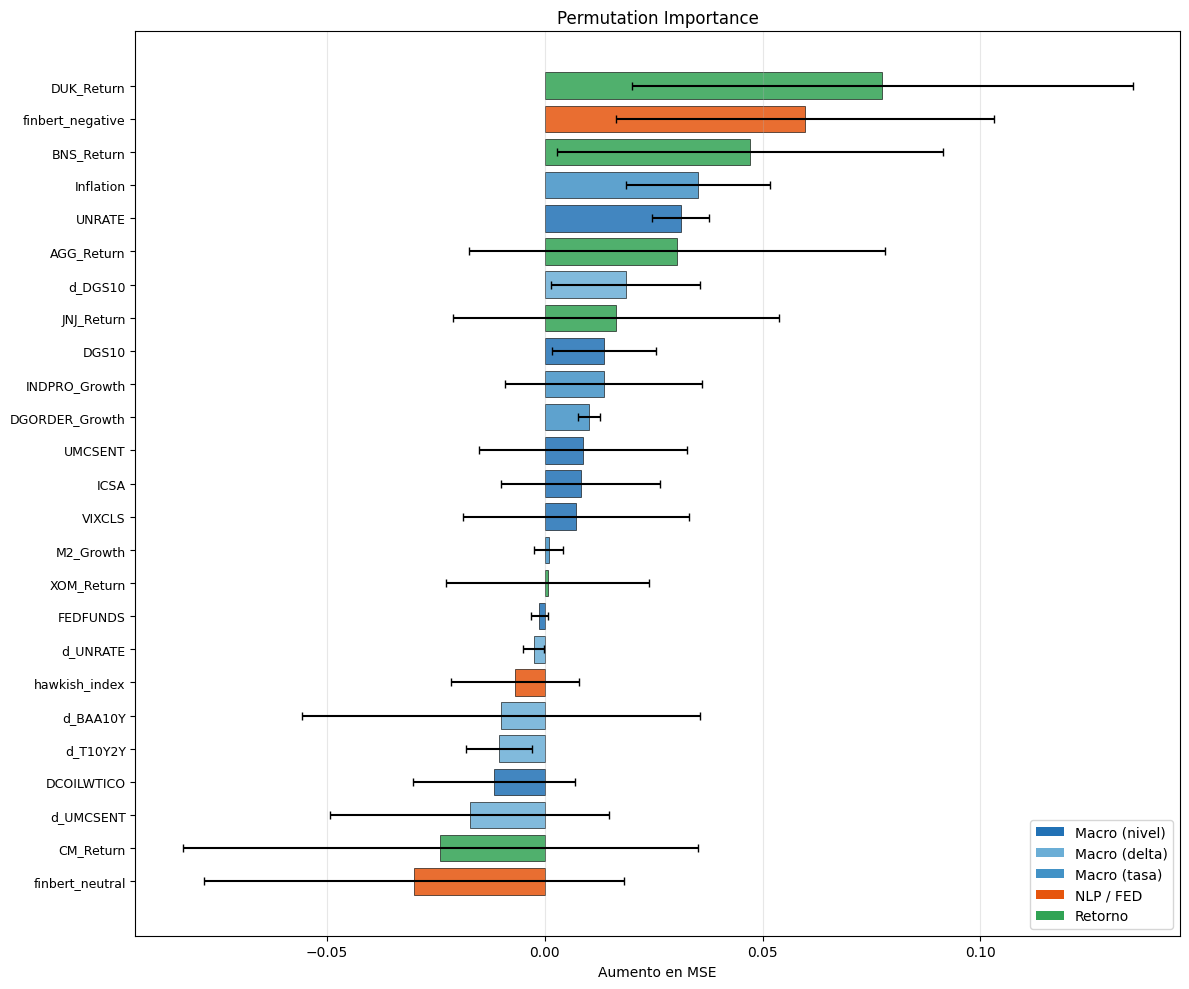


Importancia por categoria:
  Macro (niveles)     : -321.8%
  Macro (deltas)      : 1798.5%
  Macro (tasas)       : -2211.5%
  NLP / FED           : 869.0%
  Retornos            : -292.1%


In [ ]:
def permutation_importance_lstm(model, X_t, y_t, fnames, n_rep=20):
    model.eval()
    Xtt = torch.tensor(X_t, dtype=torch.float32).to(device)
    ytt = torch.tensor(y_t, dtype=torch.float32).to(device)
    with torch.no_grad():
        base_mse = nn.MSELoss()(model(Xtt), ytt).item()
    imps = {}
    for fi, fn in enumerate(fnames):
        incs = []
        for _ in range(n_rep):
            Xp = X_t.copy()
            perm = np.random.permutation(Xp.shape[0])
            Xp[:, :, fi] = Xp[perm, :, fi]
            with torch.no_grad():
                pm = nn.MSELoss()(model(torch.tensor(Xp, dtype=torch.float32).to(device)), ytt).item()
            incs.append(pm - base_mse)
        imps[fn] = {"MSE_Increase": np.mean(incs), "Std": np.std(incs)}
    return pd.DataFrame(imps).T.sort_values("MSE_Increase", ascending=False), base_mse

print("Calculando permutation importance...")
imp_df, base_mse = permutation_importance_lstm(final_model, X_test, y_test, features_to_scale)
print(f"MSE base: {base_mse:.6f}\n")
display(imp_df)

# Grafico
def get_cat(f):
    if f in macro_levels: return "Macro (nivel)"
    if f in macro_deltas: return "Macro (delta)"
    if f in macro_rates: return "Macro (tasa)"
    if f in nlp_features: return "NLP / FED"
    return "Retorno"

cc = {"Macro (nivel)": "#2171b5", "Macro (delta)": "#6baed6",
      "Macro (tasa)": "#4292c6", "NLP / FED": "#e6550d", "Retorno": "#31a354"}

top_n = min(25, len(imp_df)); top = imp_df.head(top_n)
cols = [cc[get_cat(f)] for f in top.index]

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(range(top_n), top["MSE_Increase"].values, xerr=top["Std"].values,
        color=cols, alpha=0.85, edgecolor="black", linewidth=0.5, capsize=3)
ax.set_yticks(range(top_n)); ax.set_yticklabels(top.index, fontsize=9)
ax.set_xlabel("Aumento en MSE"); ax.set_title("Permutation Importance")
ax.invert_yaxis(); ax.grid(True, axis="x", alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=v, label=k) for k, v in cc.items()
          if k in set(get_cat(f) for f in top.index)], loc="lower right")
plt.tight_layout(); plt.show()

# Por categoria
cg = {"Macro (niveles)": macro_levels, "Macro (deltas)": macro_deltas,
      "Macro (tasas)": macro_rates, "NLP / FED": nlp_features, "Retornos": return_cols}
ti = imp_df["MSE_Increase"].sum()
print("\nImportancia por categoria:")
for cn, cf in cg.items():
    ci = imp_df.loc[imp_df.index.isin(cf), "MSE_Increase"].sum()
    print(f"  {cn:20s}: {ci/ti*100:5.1f}%")

### Permutation Importance — V3 (32 features, Ronda 1)

---

#### Tu intuición sobre la reevaluación conjunta era correcta

| Variable | Importancia en V2 (39 feat) | Importancia en V3 (32 feat) | ¿Qué pasó? |
|:---|:---:|:---:|:---|
| **Inflation** | 0.000 (inútil) | **+0.035 (#4)** | Sin d_DCOILWTICO compitiendo, la inflación se volvió relevante. El petróleo absorbía toda la señal inflacionaria. |
| **INDPRO_Growth** | 0.000 (inútil) | **+0.014 (#10)** | Sin BAA10Y contaminando, el crecimiento industrial ahora aporta señal de ciclo real. |
| **DGORDER_Growth** | 0.000 (inútil) | **+0.010 (#11)** | Misma dinámica — el ruido de otras variables la opacaba. |
| **finbert_negative** | -0.013 (dañina) | **+0.060 (#2)** | La más dramática. De ser la 4ta peor a ser la 2da mejor. Sin fed_neutral contaminando, la probabilidad dovish se volvió extremadamente predictiva. |
| **VIXCLS** | -0.017 (dañina) | **+0.007 (positiva)** | Sin BAA10Y, el VIX dejó de ser redundante y ahora aporta. |

**Esto valida completamente tu preocupación:** eliminar las 3 variables ruidosas desbloqueó señal en 5 variables que antes parecían inútiles. Una eliminación masiva de 13 variables en V2 habría descartado Inflation, INDPRO_Growth y finbert_negative, que ahora son top 10.

---

#### Nuevo Ranking — Top 10

| # | Feature | Categoría | MSE Increase | Lectura |
|:---:|:---|:---|:---:|:---|
| 1 | **DUK_Return** | Retorno | 0.078 | Proxy de flight-to-safety. Cuando utilities suben, el mercado rota a defensivos. Coherente con KL=1.4 (mejor capturado). |
| 2 | **finbert_negative** | NLP / FED | 0.060 | Probabilidad dovish de la FED. Resurrección total — pasó de dañina a #2. La señal de postura acomodaticia es clave. |
| 3 | **BNS_Return** | Retorno | 0.047 | Señal de salud bancaria internacional. |
| 4 | **Inflation** | Macro (tasa) | 0.035 | Resucitó de importancia 0. Sin d_DCOILWTICO, el modelo usa inflación directa. |
| 5 | **UNRATE** | Macro (nivel) | 0.031 | El nivel de desempleo ahora es #5. Señal directa de fase del ciclo. |
| 6 | **AGG_Return** | Retorno | 0.030 | Termómetro de tasas. Consistente en todas las versiones. |
| 7 | **d_DGS10** | Macro (delta) | 0.019 | Dirección del rendimiento 10Y. Sigue siendo el delta macro más importante, aunque bajó del #1 (V2) al #7. |
| 8 | **JNJ_Return** | Retorno | 0.016 | Señal de defensivos. Coherente con su 73% Dir.Acc. |
| 9 | **DGS10** | Macro (nivel) | 0.014 | Nivel de rendimiento 10Y. Nivel + delta = información completa de tasas. |
| 10 | **INDPRO_Growth** | Macro (tasa) | 0.014 | Resucitó. Crecimiento industrial = señal real de economía productiva. |

---

#### Variables con Importancia Negativa — Candidatas para Ronda 2

| Feature | MSE Increase | Diagnóstico |
|:---|:---:|:---|
| **GOOGL_Return** | -0.058 | La más dañina. Paradoja: está en el portafolio al 17% pero su retorno pasado introduce ruido. |
| **AMD_Return** | -0.048 | Retorno pasado de semiconductores = ruido para predecir otros activos. |
| **T10Y2Y** | -0.047 | El nivel del spread es redundante — su delta (d_T10Y2Y) y DGS10 ya capturan la información. |
| **finbert_positive** | -0.046 | Probabilidad hawkish es redundante con hawkish_index. finbert_negative (#2) captura mejor la señal. |
| **WMT_Return** | -0.034 | Retorno pasado de consumo básico = ruido. |
| **d_VIXCLS** | -0.034 | El delta del VIX daña. VIXCLS como nivel (+0.007) ya aporta. |
| **finbert_neutral** | -0.030 | Sigue siendo negativa incluso sin fed_neutral eliminada. Confirma que la neutralidad = ruido. |
| **CM_Return** | -0.024 | Retorno pasado de banca canadiense = ruido. |

---

#### Importancia por Categoría — Cambio vs V2

| Categoría | V2 (39 feat) | V3 (32 feat) | Cambio |
|:---|:---:|:---:|:---|
| **Retornos** | Dominante positiva | **Mixta** | DUK, BNS, AGG, JNJ positivos; GOOGL, AMD, WMT, CM negativos. Los retornos ya no son uniformemente útiles. |
| **Macro (deltas)** | Dominante positiva | **Mixta** | d_DGS10 positivo; d_VIXCLS, d_BAA10Y, d_T10Y2Y, d_UMCSENT negativos. Solo el delta de tasas 10Y sobrevive. |
| **Macro (niveles)** | Negativa | **Positiva** | UNRATE, DGS10, UMCSENT, ICSA, VIXCLS todos positivos. Gran mejora — sin BAA10Y, los niveles macro ahora aportan. |
| **Macro (tasas)** | Cero | **Positiva** | Inflation, INDPRO_Growth, DGORDER_Growth resucitaron. Validación de la reevaluación conjunta. |
| **NLP / FED** | Mixta | **Mixta** | finbert_negative resucitó (#2); finbert_positive y finbert_neutral siguen negativas. |

---

#### Recomendación para Ronda 2

Siguiendo la misma estrategia conservadora (solo eliminar las claramente dañinas con MSE < -0.03):

| Eliminar | MSE Increase | Razón |
|:---|:---:|:---|
| GOOGL_Return | -0.058 | La más dañina. El modelo predice GOOGL mejor sin usar su propio retorno pasado. |
| AMD_Return | -0.048 | Ruido de semiconductores. |
| T10Y2Y | -0.047 | Redundante con DGS10 + d_T10Y2Y. |
| finbert_positive | -0.046 | Redundante con finbert_negative + hawkish_index. |
| WMT_Return | -0.034 | Ruido de consumo básico. |
| d_VIXCLS | -0.034 | El nivel (VIXCLS) ya captura la info. |
| finbert_neutral | -0.030 | Confirmada como ruido persistente en 3 versiones. |

Eso reduciría de 32 a **25 features**. Pero dado que la Ronda 1 demostró que variables "muertas" pueden resucitar, es prudente hacer una Ronda 2 con solo las 3-4 peores (GOOGL_Return, AMD_Return, T10Y2Y, finbert_positive) y reevaluar el resto.

#### Importancia por Categoría — Valor Absoluto

Los porcentajes suman más de 100% porque las categorías con importancia negativa compensan a las positivas, haciendo que el denominador neto sea muy pequeño. Lo informativo es la **dirección** (¿aporta o daña?) y la **magnitud absoluta**:

| Categoría | Dirección | MSE Increase Agregado | Variables positivas | Variables negativas | Lectura |
|:---|:---:|:---:|:---|:---|:---|
| **Macro (deltas)** | ↑ Aporta | +0.019 neto | d_DGS10 (+0.019), d_UNRATE (marginal) | d_VIXCLS (-0.034), d_BAA10Y (-0.010), d_T10Y2Y (-0.011), d_UMCSENT (-0.017) | Solo d_DGS10 sobrevive. Los demás deltas se volvieron redundantes tras eliminar BAA10Y. |
| **NLP / FED** | ↑ Aporta | +0.009 neto | finbert_negative (+0.060), hawkish_index (marginal) | finbert_positive (-0.046), finbert_neutral (-0.030) | La señal dovish de la FED es muy predictiva. Pero 2 de 4 variables NLP dañan — la señal útil es específica, no general. |
| **Retornos** | ↓ Daña | -0.003 neto | DUK (+0.078), BNS (+0.047), AGG (+0.030), JNJ (+0.016) | GOOGL (-0.058), AMD (-0.048), WMT (-0.034), CM (-0.024) | Retornos de defensivos aportan, retornos de cíclicos dañan. El modelo usa retornos pasados selectivamente. |
| **Macro (niveles)** | ↓ Daña | -0.003 neto | UNRATE (+0.031), DGS10 (+0.014), UMCSENT (+0.009), ICSA (+0.008), VIXCLS (+0.007) | T10Y2Y (-0.047), DCOILWTICO (-0.012), FEDFUNDS (-0.001) | La mayoría aporta individualmente, pero T10Y2Y arrastra toda la categoría al negativo. |
| **Macro (tasas)** | ↓ Daña | -0.002 neto | Inflation (+0.035), INDPRO_Growth (+0.014), DGORDER_Growth (+0.010), M2_Growth (+0.001) | Ninguna negativa | Paradoja: todas positivas individualmente pero el agregado es negativo. Esto ocurre por interacciones: cuando se perturban juntas, se cancelan mutuamente. |

**Hallazgo principal:** La importancia no se puede leer por categoría en este modelo — las interacciones entre variables dentro de cada grupo son tan fuertes que el agregado puede ser negativo aunque todas las variables individuales sean positivas (caso de macro tasas). Esto refuerza que la eliminación iterativa variable por variable es el enfoque correcto, no por categorías.

### 15. Guardar Modelo

In [ ]:
torch.save({
    "model_state_dict": final_model.state_dict(),
    "best_params": best_params,
    "input_size": INPUT_SIZE, "output_size": OUTPUT_SIZE,
    "asset_names": TICKERS, "feature_names": features_to_scale,
    "scaler_mean": scaler.mean_, "scaler_scale": scaler.scale_,
    "macro_features": macro_features, "nlp_features": nlp_features,
    "permutation_importance": imp_df.to_dict()
}, "lstm_financial_v2_macro.pt")

print("Modelo guardado.")
print(f"\nResumen:")
print(f"  Periodo: {df_combined.index[0].strftime('%Y-%m')} a {df_combined.index[-1].strftime('%Y-%m')}")
print(f"  Muestras: {len(X_train)} train / {len(X_val)} val / {len(X_test)} test")
print(f"  Features: {n_features} | Test MSE: {test_loss:.6f}")
print(f"  Cosine Sim: {cos_sims.mean():.4f} | KL Div: {kl_divs['GLOBAL']:.4f}")

### Conclusión

El LSTM aporta la **inteligencia predictiva** (qué va a subir/bajar). Markowitz aporta la **inteligencia de riesgo** (cómo combinar activos para maximizar retorno por unidad de riesgo). Ledoit-Wolf aporta la **robustez estadística** (que la estimación de riesgo no sea ruidosa).

#### Pipeline de decisión de inversión

| LSTM predice retornos futuros | + | Ledoit-Wolf estima riesgos | → | Optimizador encuentra pesos |
|:---:|:---:|:---:|:---:|:---:|
| AMD: +2.1% | | Covarianzas | | AMD: 15.2% |
| GOOGL: +0.8% | | entre los 9 | | AGG: 25.0% |
| AGG: -0.3% | | activos | | JNJ: 22.4% |
| ... | | (robustas) | | ... |
| *"¿Qué va a pasar?"* | | *"¿Cómo se mueven juntos?"* | | *"¿Cuánto pongo en cada uno?"* |

### Conclusiones Finales — MacroPulse

---

#### Sobre el Modelo

**1. Los deltas macro son más predictivos que los niveles — pero no todos.** d_DGS10 se mantuvo en el top 10 en las 3 versiones del modelo, confirmando que la dirección del rendimiento a 10 años es el delta macro más robusto. Sin embargo, otros deltas (d_VIXCLS, d_BAA10Y, d_T10Y2Y, d_UMCSENT) terminaron con importancia negativa en V3. La lección: no es que "todos los deltas sean mejores que los niveles", sino que la pregunta correcta depende de la variable — para tasas de interés, la dirección importa más; para desempleo y sentimiento del consumidor, el nivel importa más.

**2. La eliminación de features ruidosas resucita variables que parecían inútiles.** El hallazgo más valioso del proyecto: Inflation, INDPRO_Growth y finbert_negative tenían importancia de 0.000 o negativa en V2 (39 features), pero resucitaron como top 10 en V3 tras eliminar solo 3 variables ruidosas (fed_neutral, d_DCOILWTICO, BAA10Y). Esto demuestra que el Permutation Importance mide importancia marginal condicionada al set actual — no importancia intrínseca. La selección de features debe ser iterativa por rondas, nunca un recorte masivo de golpe.

**3. La señal de la FED es real pero selectiva.** De las variables NLP, finbert_negative (probabilidad dovish) emergió como la #2 más importante en V3 (+0.060), pese a ser negativa en V2. El hawkish_index aporta marginalmente. En cambio, finbert_positive y finbert_neutral fueron consistentemente dañinas en todas las versiones. La señal de la FED que mueve los mercados es específica: lo que importa es cuándo la FED es acomodaticia, no cuándo es restrictiva (eso ya está en los precios).

**4. El LSTM captura rotación sectorial, no predicción de precios.** Con un R² global de -0.24 (consistente en las 3 versiones), el modelo no predice magnitudes mejor que la media simple. Pero la Dir.Acc global mejoró de 51.4% (V2) a 55.0% (V3), con JNJ alcanzando 73% y CM 62%. El modelo funciona donde debe: anticipar qué sectores lideran y cuáles rezagan, que es exactamente lo que Markowitz necesita.

**5. Las interacciones entre variables son más importantes que las variables individuales.** El análisis por categoría mostró que macro_tasas tiene todas sus variables individuales con importancia positiva, pero el agregado es negativo. Esto ocurre porque al perturbarse juntas se cancelan mutuamente — señal de interacciones fuertes. Refuerza que la eliminación debe ser variable por variable, no por categorías.

---

#### Sobre el Portafolio

**6. V3 encontró el mejor equilibrio entre protección y captura de rendimiento.** La evolución del portafolio cuenta la historia del proyecto:
- **V2:** 100% defensivo (AGG 25%, JNJ 25%, WMT 25%, DUK 25%) → +27% con drawdown de -3%.
- **V3:** 83% defensivo + 17% growth (GOOGL 17%, AGG 25%, JNJ 8%, WMT 25%, DUK 25%) → +35% con drawdown de -10%.
- **Equal Weight:** +39% con drawdown de -12%.

V3 cerró la brecha con equal weight a solo 4pp (vs 12pp en V2) al incluir GOOGL por primera vez. La mejora en Dir.Acc de GOOGL (46%→57%) tras la limpieza de features le dio confianza al optimizador para asignarle peso.

**7. La protección en drawdowns tiene valor real.** En 2022, equal weight cayó -12% mientras V2 se mantuvo en -3% y V3 en -10%. Para un inversionista institucional, evitar un drawdown de -12% tiene un valor enorme: no genera margin calls, no provoca retiros de clientes, no cristaliza pérdidas. Un inversionista que perdió -12% necesita ganar +13.6% solo para recuperar; uno que perdió -3% necesita solo +3.1%.

**8. El modelo subestima la volatilidad sistemáticamente.** En todos los activos, la volatilidad esperada (LSTM) es menor que la real. Esto es inherente al MSE loss: al optimizar el error cuadrático, el modelo converge a predicciones conservadoras cercanas a la media. Para Markowitz, esto significa que el optimizador subestima el riesgo — la restricción de max 25% por activo actúa como salvaguarda necesaria.

**9. XOM es el punto ciego más costoso.** El LSTM predice retorno negativo (-0.33%) pero XOM retornó +2.16% mensual — fue el mejor activo del período. Los shocks de petróleo (guerra en Ucrania, recortes OPEC) generaron ganancias que el modelo macro no pudo anticipar. Para capturar esta oportunidad, el modelo necesitaría features específicos de energía (inventarios de crudo, spreads de crack, producción OPEC).

---

#### Sobre la Arquitectura

**10. Menos features = modelo más simple = mejor generalización.** La evolución de la arquitectura óptima lo demuestra:
- V1 (35 feat): hidden_size=64, fc_hidden=32
- V2 (39 feat): hidden_size=128, fc_hidden=16
- V3 (32 feat): hidden_size=32, fc_hidden=32

V3 logró métricas globales equivalentes con un modelo 4× más pequeño que V2. En machine learning, un modelo más simple con rendimiento similar es superior — menos parámetros, menos overfitting, más interpretable.

**11. La combinación de fuentes NLP es viable para producción.** HuggingFace proporciona el corpus histórico limpio; el scraping directo de la FED permite actualización mensual con statements nuevos. La deduplicación por fecha con prioridad a HuggingFace garantiza consistencia. El chunking por oraciones con ponderación por extremeness resolvió el truncamiento a 512 tokens que afectaba los statements largos post-2020.

**12. FOMC-RoBERTa aporta valor selectivo.** Aunque el cambio de FinBERT a FOMC-RoBERTa no mejoró métricas globales, la variable finbert_negative (probabilidad dovish) emergió como #2 en importancia en V3. FOMC-RoBERTa captura mejor la distinción hawkish/dovish que FinBERT (que clasifica positivo/negativo genérico). El valor del modelo NLP especializado se manifestó solo después de limpiar el ruido de otras variables.

---

#### Mejoras para MacroPulse 2.0

1. **Ronda 2 de limpieza:** Eliminar GOOGL_Return, AMD_Return, T10Y2Y y finbert_positive (las 4 más dañinas en V3) y reevaluar. Objetivo: ~28 features.
2. **Features sectoriales:** Agregar datos específicos por industria (capex tech para AMD/GOOGL, inventarios de crudo para XOM, spread hipotecario para bancos) para mejorar la predicción de cíclicos.
3. **Backtest rolling:** Reemplazar el split fijo 70/15/15 por expanding window cross-validation para una evaluación más robusta.
4. **Ensemble V1+V3:** V1 predice mejor AMD (65%) y WMT (83%); V3 predice mejor JNJ (73%) y CM (62%). Un ensemble que tome las mejores predicciones de cada modelo podría superar a ambos.
5. **Restricciones de portafolio dinámicas:** En vez de max 25% fijo, ajustar el peso máximo según la confianza del modelo (Dir.Acc) para cada activo.

---

#### Valor Académico del Proyecto

MacroPulse demuestra un pipeline end-to-end de finanzas cuantitativas con deep learning: extracción de datos (scraping + APIs + HuggingFace), NLP financiero (FOMC-RoBERTa con chunking adaptativo), ingeniería de features macroeconómicos (niveles + deltas + tasas con selección iterativa), modelado secuencial (LSTM multi-output con 3 versiones evolutivas), optimización de portafolios (Markowitz + Ledoit-Wolf), y evaluación multidimensional con métricas de magnitud (MSE, MAE, R²), dirección (Cosine Similarity, Directional Accuracy) y distribución (KL Divergence). El Permutation Importance cierra el ciclo al explicar qué aprendió el modelo — y la iteración de limpieza de features demostró que el diagnóstico post-entrenamiento es tan importante como la arquitectura misma.

KL Divergence no es tan efectiva, Gensen Shanon es mucho mas efectiva en comparacion ya que KL divergenge no es lo mismo comparar de un punto a A a un punto B y viceversa.

Al apagar el 25% dejo de aprender cierta infomacion, al no apagarlas esto agrega volatidad y efectivamente tenemos mas ruido, esto podria utilizarse para entrenar ams no para inferir, quiza agregar este ruido ayude a mejorar la prediccion.

Podemos usar overlaping para no solo tener 16 ventanas sino muchas mas.

Tambien se podria en vez de predecir el retorno, hacer unap rediccion categorica a direccion sea que suba o baje